#edity dist avec crossdvalid dedans et knn 7 et clysqtrert 50

--- Début du Chargement ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_7712\2306698995.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 139615
Standardisation des données...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_7712\2306698995.py:73: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture)


Resampling à 100 points...
Test sur sujet sorti : 1
Précision split : 94.00%
Test sur sujet sorti : 2
Précision split : 87.00%
Test sur sujet sorti : 3
Précision split : 85.00%
Test sur sujet sorti : 4
Précision split : 87.00%
Test sur sujet sorti : 5
Précision split : 78.00%
Test sur sujet sorti : 6
Précision split : 87.00%
Test sur sujet sorti : 7
Précision split : 99.00%
Test sur sujet sorti : 8
Précision split : 94.00%
Test sur sujet sorti : 9
Précision split : 100.00%
Test sur sujet sorti : 10
Précision split : 86.00%

=== EXACTITUDE GLOBALE : 89.70% ===


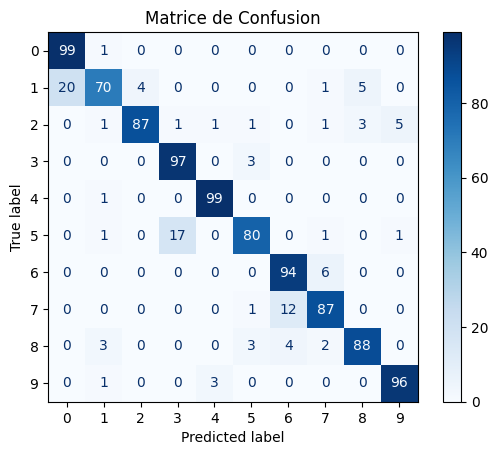

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d




DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé"

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except FileNotFoundError:
                continue
            except Exception:
                continue

print(f"Nombre total d'observations chargées : {len(df)}")


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)



def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation des données...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    groups = df_input.groupby(["gesture", "subject", "iter"])

    for (gesture, subject, iteration), group in groups:
        n = len(group)
        if n < 2: continue

        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)

        res_dict = {
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len
        }

        for col in ["x_std", "y_std", "z_std"]:
            res_dict[col] = interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame(res_dict))

    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à 100 points...")
df100 = resample_gesture(df)



def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def gesture_to_sequence(df_sym):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_sym.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def assign_symbols(df_local):
        pts = df_local[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_copy = df_local.copy()
        df_copy["symbol"] = symbols
        return df_copy

    return gesture_to_sequence(assign_symbols(df_train)), gesture_to_sequence(assign_symbols(df_test))

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]


def dict_creation_userout(df_in, subj_out):
    return df_in[df_in["subject"] != subj_out], df_in[df_in["subject"] == subj_out]

def testmodel(df_target, loop_range=10, k_knn=7, k_clusters=50):
    total_true, total_pred = [], []

    for i in range(1, loop_range + 1):
        print(f"Test sur sujet sorti : {i}")
        train_df, test_df = dict_creation_userout(df_target, i)

        if test_df.empty: continue

        train_seq, test_seq = cluster_and_convert(train_df, test_df, k_clusters)

        y_true, y_pred = [], []
        for gesture, sequences in test_seq.items():
            for seq in sequences:
                pred = knn_edit_predict(seq, train_seq, k=k_knn)
                y_true.append(gesture)
                y_pred.append(pred)

        total_true.extend(y_true)
        total_pred.extend(y_pred)
        print(f"Précision split : {accuracy_score(y_true, y_pred):.2%}")


    print(f"\n=== EXACTITUDE GLOBALE : {accuracy_score(total_true, total_pred):.2%} ===")
    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de Confusion")
    plt.show()


testmodel(df100)

# lcss knn 3 clsurr 20

--- Début du Chargement ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_6248\3286419123.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 139615
Standardisation en cours...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_6248\3286419123.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

--- TEST SUJET SORTI : 1 ---
Précision sujet 1 : 82.00%

--- TEST SUJET SORTI : 2 ---
Précision sujet 2 : 77.00%

--- TEST SUJET SORTI : 3 ---
Précision sujet 3 : 74.00%

--- TEST SUJET SORTI : 4 ---
Précision sujet 4 : 86.00%

--- TEST SUJET SORTI : 5 ---
Précision sujet 5 : 77.00%

--- TEST SUJET SORTI : 6 ---
Précision sujet 6 : 80.00%

--- TEST SUJET SORTI : 7 ---
Précision sujet 7 : 95.00%

--- TEST SUJET SORTI : 8 ---
Précision sujet 8 : 86.00%

--- TEST SUJET SORTI : 9 ---
Précision sujet 9 : 100.00%

--- TEST SUJET SORTI : 10 ---
Précision sujet 10 : 75.00%

=== EXACTITUDE GLOBALE KNN-LCSS : 83.20% ===


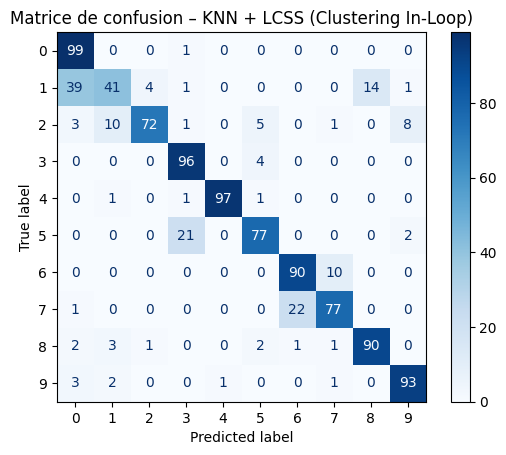

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d




DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé"

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des meta-données
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except FileNotFoundError:
                continue
            except Exception:
                continue


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")



def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:

        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)



def cluster_and_symbolize(train_df, test_df, k_clusters=20):

    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)

        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append("".join(group['symbol'].tolist()))
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)


def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):

    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = lcs_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def testmodel(df_input, loop_range=10, k_knn=3, k_clusters=20):
    total_true, total_pred = [], []

    for i in range(1, loop_range + 1):

        train_df = df_input[df_input["subject"] != i]
        test_df = df_input[df_input["subject"] == i]

        if test_df.empty:
            continue

        print(f"\n--- TEST SUJET SORTI : {i} ---")


        train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

        y_true, y_pred = [], []
        for gesture, sequences in test_dict.items():
            for seq in sequences:
                pred = knn_lcs_predict(seq, train_dict, k=k_knn)
                y_true.append(gesture)
                y_pred.append(pred)

        acc = accuracy_score(y_true, y_pred)
        print(f"Précision sujet {i} : {acc:.2%}")
        total_true.extend(y_true)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE KNN-LCSS : {final_acc:.2%} ===")


    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – KNN + LCSS (Clustering In-Loop)")
    plt.show()


testmodel(df100)

#trans

--- 1. Début du Chargement du Domaine 4 ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé
Nombre total d'observations chargées : 139615


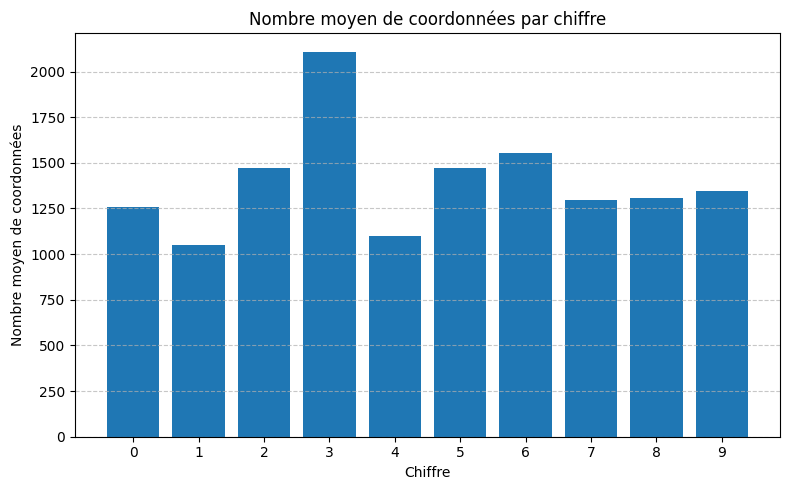

Chiffre 0 : 5617.80 s
Chiffre 1 : 4471.30 s
Chiffre 2 : 6968.80 s
Chiffre 3 : 9840.80 s
Chiffre 4 : 4995.50 s
Chiffre 5 : 6658.20 s
Chiffre 6 : 7136.30 s
Chiffre 7 : 5698.10 s
Chiffre 8 : 6041.50 s
Chiffre 9 : 6774.80 s


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_6284\1615355736.py:108: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



--- Test subject OUT : 1 ---

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 217ms/step - accuracy: 0.1011 - loss: 2.4170
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 220ms/step - accuracy: 0.4133 - loss: 1.5941
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - accuracy: 0.7656 - loss: 0.6322
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.8756 - loss: 0.3411
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.9189 - loss: 0.2694
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.9600 - loss: 0.1469
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.9533 - loss: 0.1583
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.9767 - loss: 0.0853
Epoch 9/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.9822 - loss: 0.0821
Epoch 10/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.9767 - loss: 0.0627
Epoch 11/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.9789 - loss: 0.0766
Epoch 12/50
29/29 ━━

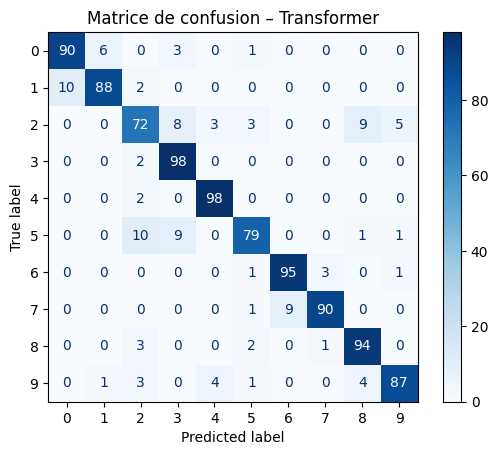

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf




DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé"
DOMAIN_ID = 4


df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2: continue


                data = file[0].str.strip('"').str.split(',', expand=True)

                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df_list.append(file_df)

            except FileNotFoundError:
                continue
            except Exception:
                continue


if not df_list:
    raise ValueError("Aucun fichier n'a pu être chargé. Vérifiez le chemin et le format des fichiers.")

df = pd.concat(df_list, ignore_index=True)


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")



grouped = df.groupby(['gesture', 'iter'])
sequence_lengths = grouped.size().reset_index(name='length')
mean_lengths = sequence_lengths.groupby('gesture')['length'].mean().reset_index()
mean_lengths.columns = ['Chiffre', 'Frames moyennes']

plt.figure(figsize=(8, 5))
plt.bar(mean_lengths["Chiffre"], mean_lengths["Frames moyennes"])
plt.title("Nombre moyen de coordonnées par chiffre")
plt.xlabel("Chiffre")
plt.ylabel("Nombre moyen de coordonnées")
plt.xticks(mean_lengths["Chiffre"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
for gesture, mean_dur in mean_durations.items():
    print(f"Chiffre {gesture} : {mean_dur:.2f} s")



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        if std == 0 or np.isnan(std):
            df_copy[f'{axis}_std'] = 0.0
        else:
            df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)




def resample_gesture(df_in, target_len=100):
    resampled_data = []

    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue

        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))

    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)




def create_user_independent_split(df_in, subj_out):
    train_df = df_in[df_in['subject'] != subj_out]
    test_df = df_in[df_in['subject'] == subj_out]

    def df_to_array(df_target):
        X, y = [], []
        for (gesture, subject, iteration), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(gesture)
        return np.array(X), np.array(y)

    X_train, y_train = df_to_array(train_df)
    X_test, y_test = df_to_array(test_df)
    return X_train, y_train, X_test, y_test




class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]




def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn = models.Sequential([
        layers.Dense(dff, activation="relu"),
        layers.Dense(d_model),
    ])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)
    return out2

def create_transformer_model(input_shape, num_classes, seq_len=100):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2

    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(seq_len, d_model)(x)

    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model




def test_transformer_user_independent(df_data, loop_range=10, epochs=30, batch_size=32, verbose_fit=1):
    total_true, total_pred = [], []

    for subj_out in range(1, loop_range + 1):
        if df_data[df_data['subject'] == subj_out].empty: continue

        print(f"\n--- Test subject OUT : {subj_out} ---")
        X_train, y_train, X_test, y_test = create_user_independent_split(df_data, subj_out)

        n_classes = len(np.unique(df_data['gesture']))
        input_shape = (X_train.shape[1], X_train.shape[2])

        model = create_transformer_model(input_shape=input_shape, num_classes=n_classes)
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=verbose_fit)

        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)
        print(f"Exactitude subject {subj_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\nExactitude globale Transformer : {final_acc:.2%}")

    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – Transformer")
    plt.show()

test_transformer_user_independent(df100, loop_range=10, epochs=50, batch_size=32, verbose_fit=1)

# lstm batch size 32

--- 1. Début du Chargement du Domaine 4 ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé
✅ Nombre total d'observations chargées : 139615

--- 2. Analyse Exploratoire ---


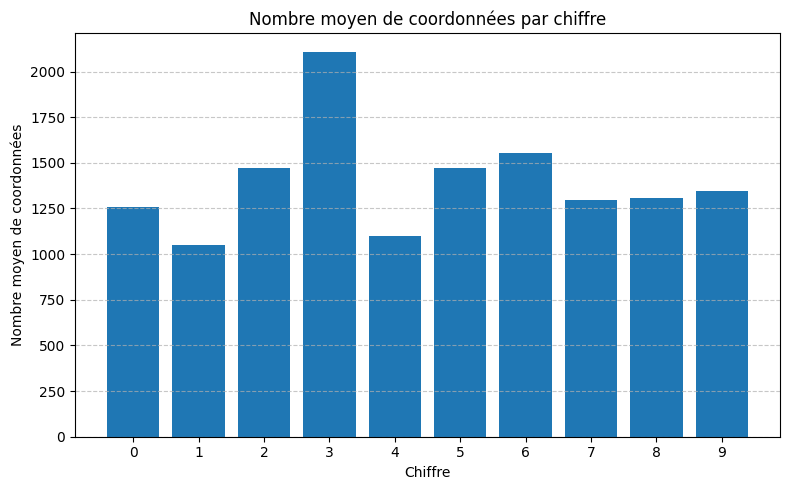

Chiffre 0 : 5617.80 s
Chiffre 1 : 4471.30 s
Chiffre 2 : 6968.80 s
Chiffre 3 : 9840.80 s
Chiffre 4 : 4995.50 s
Chiffre 5 : 6658.20 s
Chiffre 6 : 7136.30 s
Chiffre 7 : 5698.10 s
Chiffre 8 : 6041.50 s
Chiffre 9 : 6774.80 s

Standardisation...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_10152\347728140.py:105: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling à longueur 100...

--- Test subject OUT : 1 ---


\\student.fucam.ac.be\users$\isadiki\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 1 : 93.00%

--- Test subject OUT : 2 ---


...

Exactitude subject 8 : 81.00%

--- Test subject OUT : 9 ---


\\student.fucam.ac.be\users$\isadiki\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 9 : 100.00%

--- Test subject OUT : 10 ---


\\student.fucam.ac.be\users$\isadiki\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 10 : 78.00%

Exactitude globale LSTM : 88.70%


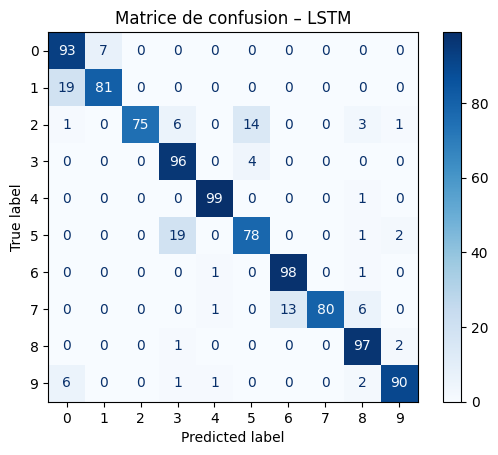

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers




DOMAIN_FOLDER = r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé"
DOMAIN_ID = 4

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2: continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df_list.append(file_df)

            except (FileNotFoundError, Exception):
                continue


if not df_list:
    raise ValueError("❌ Aucun fichier n'a été chargé. Vérifiez le chemin : " + DOMAIN_FOLDER)

df = pd.concat(df_list, ignore_index=True)


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"✅ Nombre total d'observations chargées : {len(df)}")



print("\n--- 2. Analyse Exploratoire ---")
grouped = df.groupby(['gesture', 'iter'])
sequence_lengths = grouped.size().reset_index(name='length')
mean_lengths = sequence_lengths.groupby('gesture')['length'].mean().reset_index()
mean_lengths.columns = ['Chiffre', 'Frames moyennes']

plt.figure(figsize=(8, 5))
plt.bar(mean_lengths["Chiffre"], mean_lengths["Frames moyennes"])
plt.title("Nombre moyen de coordonnées par chiffre")
plt.xlabel("Chiffre")
plt.ylabel("Nombre moyen de coordonnées")
plt.xticks(mean_lengths["Chiffre"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
for gesture, mean_dur in mean_durations.items():
    print(f"Chiffre {gesture} : {mean_dur:.2f} s")



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        if std == 0 or np.isnan(std):
            df_copy[f'{axis}_std'] = 0.0
        else:
            df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std
    return df_copy

print("\nStandardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à longueur 100...")
df100 = resample_gesture(df)



def create_user_independent_split(df_in, subj_out):
    train_df = df_in[df_in['subject'] != subj_out]
    test_df = df_in[df_in['subject'] == subj_out]

    def df_to_array(df_target):
        X, y = [], []
        for (gesture, subject, iteration), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(gesture)
        return np.array(X), np.array(y)

    X_train, y_train = df_to_array(train_df)
    X_test, y_test = df_to_array(test_df)
    return X_train, y_train, X_test, y_test



def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, dropout=0.2, input_shape=input_shape),
        layers.LSTM(256, dropout=0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model



def test_lstm_user_independent(df_data, loop_range=10, epochs=50, batch_size=32):
    total_true, total_pred = [], []
    subjects = sorted(df_data['subject'].unique())

    for subj_out in subjects:
        print(f"\n--- Test subject OUT : {subj_out} ---")
        X_train, y_train, X_test, y_test = create_user_independent_split(df_data, subj_out)


        all_labels = np.unique(df_data['gesture'])
        num_classes = int(max(all_labels) + 1)

        model = create_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]), num_classes=num_classes)


        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)


        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)
        print(f"Exactitude subject {subj_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\nExactitude globale LSTM : {final_acc:.2%}")


    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – LSTM")
    plt.show()


test_lstm_user_independent(df100)

#dtw

# dtw total

--- Début du Chargement ---
✅ Données chargées : 139615 lignes.


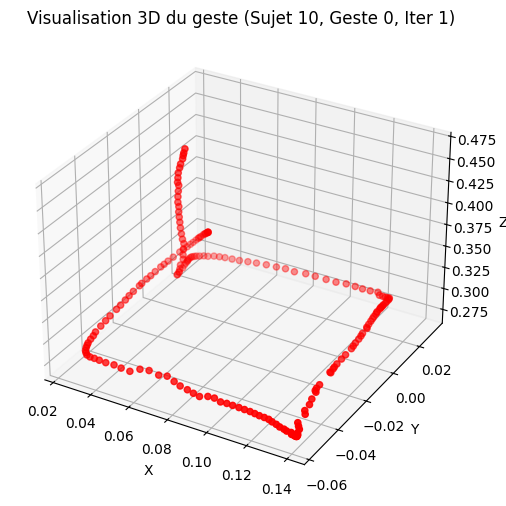


--- Durée moyenne des gestes (s) ---
gesture
0    5617.8
1    4471.3
2    6968.8
3    9840.8
4    4995.5
5    6658.2
6    7136.3
7    5698.1
8    6041.5
9    6774.8
Name: duration, dtype: float64


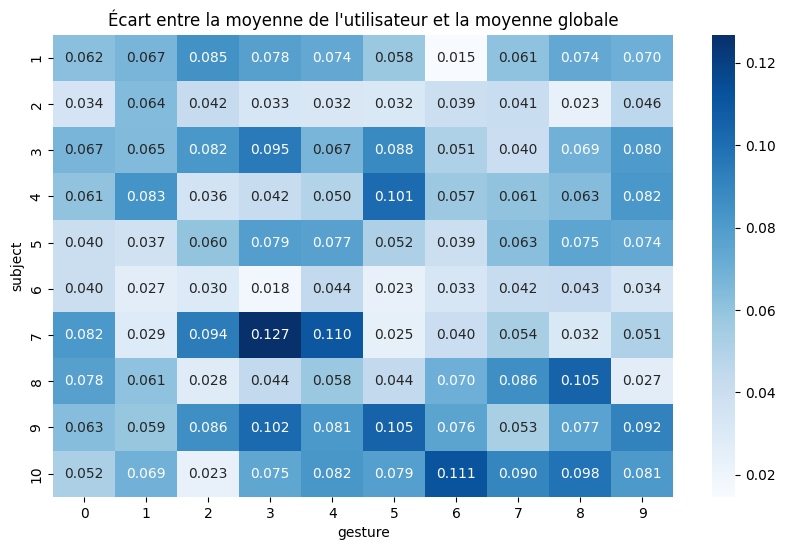

Standardisation...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_4996\1890533262.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...

--- Test Split OUT : 1 ---
Précision split 1 : 88.00%

--- Test Split OUT : 2 ---
Précision split 2 : 90.00%

--- Test Split OUT : 3 ---
Précision split 3 : 87.00%

--- Test Split OUT : 4 ---
Précision split 4 : 95.00%

--- Test Split OUT : 5 ---
Précision split 5 : 85.00%

--- Test Split OUT : 6 ---
Précision split 6 : 88.00%

--- Test Split OUT : 7 ---
Précision split 7 : 98.00%

--- Test Split OUT : 8 ---
Précision split 8 : 86.00%

--- Test Split OUT : 9 ---
Précision split 9 : 100.00%

--- Test Split OUT : 10 ---
Précision split 10 : 74.00%

✅ Précision GLOBALE : 89.10%


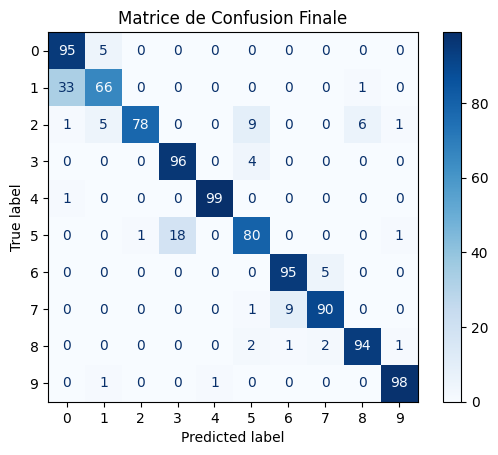

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d
import seaborn as sns



DOMAIN_FOLDER =  r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé"

df_list = []

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)

                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("❌ Aucun fichier chargé. Vérifiez le chemin : " + DOMAIN_FOLDER)

df = pd.concat(df_list, ignore_index=True)
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"✅ Données chargées : {len(df)} lignes.")



subdf = df.loc[(df['gesture'] == 0) & (df['subject'] == 10) & (df['iter'] == 1)]

if not subdf.empty:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    # ax.plot(...) a été supprimé ici pour enlever le tracé bleu
    ax.scatter(subdf['x'], subdf['y'], subdf['z'], c='red', s=20)
    ax.set_title("Visualisation 3D du geste (Sujet 10, Geste 0, Iter 1)")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()




durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
print("\n--- Durée moyenne des gestes (s) ---")
print(mean_durations)


mean_coords_user = df.groupby(['subject', 'gesture'])[['x', 'y', 'z']].mean().reset_index()
mean_coords_global = df.groupby('gesture')[['x', 'y', 'z']].mean().reset_index().rename(
    columns={'x':'x_global', 'y':'y_global', 'z':'z_global'})

merged = pd.merge(mean_coords_user, mean_coords_global, on='gesture')
merged['dist_to_global'] = np.sqrt((merged['x']-merged['x_global'])**2 +
                                   (merged['y']-merged['y_global'])**2 +
                                   (merged['z']-merged['z_global'])**2)

pivot = merged.pivot(index='subject', columns='gesture', values='dist_to_global')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='Blues')
plt.title("Écart entre la moyenne de l'utilisateur et la moyenne globale")
plt.show()



def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)



def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def dict_creation_userout(df, subj_out):
    test_df = df[df["subject"] == subj_out]
    train_df = df[df["subject"] != subj_out]

    dict_train = defaultdict(list)
    dict_test = defaultdict(list)

    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())
    for (g, s, it), group in test_df.groupby(["gesture", "subject", "iter"]):
        dict_test[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())
    return dict_train, dict_test

def testmodel(DictCreationFunc, df, loop_range=10, k=3):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        print(f"\n--- Test Split OUT : {i} ---")
        coord_train, coord_test = DictCreationFunc(df, i)
        y_true, y_pred = [], []
        for gesture, sequences in coord_test.items():
            for seq in sequences:
                pred = knn_dtw_predict(seq, coord_train, k=k)
                y_true.append(gesture)
                y_pred.append(pred)

        acc = accuracy_score(y_true, y_pred)
        total_true.extend(y_true); total_pred.extend(y_pred)
        print(f"Précision split {i} : {acc:.2%}")

    print(f"\n✅ Précision GLOBALE : {accuracy_score(total_true, total_pred):.2%}")
    cm = confusion_matrix(total_true, total_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title("Matrice de Confusion Finale")
    plt.show()

# LANCEMENT FINAL
testmodel(dict_creation_userout, df100, loop_range=10, k=3)

# partie 2

## lcss cluster 40 knn 3 traine 4 tes 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")


for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)



# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=40):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=3, k_clusters=40):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_19389/1502044339.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_19389/1502044339.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 67.78%
Précision Sujet 7 : 85.56%
Précision Sujet 8 : 83.33%
Précision Sujet 9 : 90.00%
Précision Sujet 10 : 80.00%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 81.33% ===


## lcss cluster 40 knn 3 traine 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)



# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=40):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=40):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_19389/1209672135.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_19389/1209672135.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 76.67%
Précision Sujet 2 : 75.56%
Précision Sujet 4 : 77.78%
Précision Sujet 5 : 70.00%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 75.00% ===


# lcss cluster 5 knn 3 test sur sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=5):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=5):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/2953811871.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/2953811871.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 70.00% ===


# lcss cluster 20 knn3 traine 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=3, k_clusters=20):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN4_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/3833248958.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 126156
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/3833248958.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 77.78%
Précision Sujet 7 : 93.33%
Précision Sujet 8 : 82.22%
Précision Sujet 9 : 90.00%
Précision Sujet 10 : 70.00%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 82.67% ===


# lcss cluster 20 knn 3 traine 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=20):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/2868535272.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/2868535272.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 78.89%
Précision Sujet 2 : 81.11%
Précision Sujet 4 : 76.67%
Précision Sujet 5 : 80.00%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 79.17% ===


# lcs cluster 20 knn3 test sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=20):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/3869766258.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/3869766258.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 74.44% ===


# lcss clusyter 50 knn 3 traine 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=3, k_clusters=50):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN4_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/3605467395.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 126156
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/3605467395.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 68.89%
Précision Sujet 7 : 88.89%
Précision Sujet 8 : 80.00%
Précision Sujet 9 : 91.11%
Précision Sujet 10 : 71.11%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 80.00% ===


# lcss cluster 50 knn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=50):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/4056542318.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/4056542318.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 81.11%
Précision Sujet 2 : 77.78%
Précision Sujet 4 : 72.22%
Précision Sujet 5 : 73.33%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 76.11% ===


# lcs cluster 50 knnn 3 test sur sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=50):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/682863056.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/682863056.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 76.67% ===


# lcs cluster 20 knn 5 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=5, k_clusters=20):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN4_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/1820515476.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 126156
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/1820515476.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 78.89%
Précision Sujet 7 : 92.22%
Précision Sujet 8 : 81.11%
Précision Sujet 9 : 88.89%
Précision Sujet 10 : 70.00%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 82.22% ===


# lcs cluster 20 knnn 5 traine 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=5, k_clusters=20):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/1473148943.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/1473148943.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 76.67%
Précision Sujet 2 : 81.11%
Précision Sujet 4 : 76.67%
Précision Sujet 5 : 76.67%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 77.78% ===


# lcs cluster 20 knn 5 test sur sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=5, k_clusters=20):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/488214884.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/488214884.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 74.44% ===


# lcs cluster 20 knn 7 traine 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=7, k_clusters=20):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN4_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/846898797.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 126156
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/846898797.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 80.00%
Précision Sujet 7 : 92.22%
Précision Sujet 8 : 76.67%
Précision Sujet 9 : 91.11%
Précision Sujet 10 : 70.00%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 82.00% ===


# lcs cluster 20 knn 7 traine 5 tesgt 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=7, k_clusters=20):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/1169725343.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/1169725343.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 77.78%
Précision Sujet 2 : 76.67%
Précision Sujet 4 : 75.56%
Précision Sujet 5 : 76.67%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 76.67% ===


# lcs cluster 20 knn 7 test final sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=7, k_clusters=20):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/2321203228.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/2321203228.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 75.56% ===


# edit cluster 40 knn 3 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=40):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=40):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_19389/3932694250.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_19389/3932694250.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 64.44%
Précision Sujet 7 : 88.89%
Précision Sujet 8 : 85.56%
Précision Sujet 9 : 93.33%
Précision Sujet 10 : 76.67%

=== EXACTITUDE GLOBALE : 81.78% ===


# edit cluster 40 knn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)



# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=40):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=40):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_19389/2322882190.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_19389/2322882190.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 86.67%
Précision Sujet 2 : 88.89%
Précision Sujet 4 : 83.33%
Précision Sujet 5 : 76.67%

=== EXACTITUDE GLOBALE : 83.89% ===


# edit cluster 5 knn 3 test sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=5):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=5):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1445471924.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1445471924.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 71.11% ===


# edit cluster 20 knn 3 test 5 train 4 )

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=20):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/3373129982.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/3373129982.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 71.11%
Précision Sujet 7 : 96.67%
Précision Sujet 8 : 81.11%
Précision Sujet 9 : 97.78%
Précision Sujet 10 : 72.22%

=== EXACTITUDE GLOBALE : 83.78% ===


# edit c luster 20 knn 3 train 5 tezst 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=20):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/229263192.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/229263192.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 84.44%
Précision Sujet 2 : 85.56%
Précision Sujet 4 : 86.67%
Précision Sujet 5 : 80.00%

=== EXACTITUDE GLOBALE : 84.17% ===


# edit cluster 20 knn 3 test sur sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=20):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=20):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/575744726.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/575744726.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 78.89% ===


# edit cluster 50 knn3 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=50):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/3630555954.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/3630555954.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 73.33%
Précision Sujet 7 : 91.11%
Précision Sujet 8 : 88.89%
Précision Sujet 9 : 96.67%
Précision Sujet 10 : 73.33%

=== EXACTITUDE GLOBALE : 84.67% ===


# edit cluster 50 knn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=50):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1689217240.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1689217240.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 88.89%
Précision Sujet 2 : 83.33%
Précision Sujet 4 : 86.67%
Précision Sujet 5 : 78.89%

=== EXACTITUDE GLOBALE : 84.44% ===


# edit dist cluster 50 knn 3 test sur le sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=50):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1672333672.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1672333672.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 81.11% ===


# edit cluster 50 knn 5 trzin 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=5, k_clusters=50):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/4105012169.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/4105012169.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 71.11%
Précision Sujet 7 : 94.44%
Précision Sujet 8 : 83.33%
Précision Sujet 9 : 96.67%
Précision Sujet 10 : 70.00%

=== EXACTITUDE GLOBALE : 83.11% ===


# eedit cluster 50 knn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=5, k_clusters=50):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1097578583.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1097578583.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 90.00%
Précision Sujet 2 : 82.22%
Précision Sujet 4 : 87.78%
Précision Sujet 5 : 77.78%

=== EXACTITUDE GLOBALE : 84.44% ===


# edit cluster 50 knnn 5 sueht 3 test

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=5):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=5, k_clusters=50):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1589753864.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1589753864.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 82.22% ===


# edit cluster 50 knn 7 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=7, k_clusters=50):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/2590775762.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/2590775762.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 76.67%
Précision Sujet 7 : 95.56%
Précision Sujet 8 : 78.89%
Précision Sujet 9 : 95.56%
Précision Sujet 10 : 72.22%

=== EXACTITUDE GLOBALE : 83.78% ===


# edit cluster 50 knn 7 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=7, k_clusters=50):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/2598453105.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/2598453105.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 88.89%
Précision Sujet 2 : 83.33%
Précision Sujet 4 : 86.67%
Précision Sujet 5 : 75.56%

=== EXACTITUDE GLOBALE : 83.61% ===


# edit cluster 50 knn 7 test sur sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=7, k_clusters=50):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/104785346.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/104785346.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 82.22% ===


# lstm 64 64 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(64),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

Décompression terminée !
--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_2763/359121453.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 266ms/step - accuracy: 0.3179 - loss: 2.1886 - val_accuracy: 0.0000e+00 - val_loss: 2.6007
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - accuracy: 0.3765 - loss: 1.7934 - val_accuracy: 0.0000e+00 - val_loss: 3.5046
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 157ms/step - accuracy: 0.4568 - loss: 1.3782 - val_accuracy: 0.0000e+00 - val_loss: 4.0054
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - accuracy: 0.6080 - loss: 1.0766 - val_accuracy: 0.0000e+00 - val_loss: 4.1949
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.6975 - loss: 0.8612 - val_accuracy: 0.0000e+00 - val_loss: 3.9298
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step - accuracy: 0.7932 - loss: 0.7127 - val_accuracy: 0.0000e+00 - val_loss: 4.5008
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - accuracy: 0.8179 - loss: 0.5797 - val_accuracy: 0.0000e+00 - val_loss: 4.3700
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 254ms/step - accuracy: 0.7840 - loss: 0.5335 

# lstm 64 64 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(64),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_2763/1035202685.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.3531 - loss: 2.1399 - val_accuracy: 0.0000e+00 - val_loss: 2.7277
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.4519 - loss: 1.6151 - val_accuracy: 0.0000e+00 - val_loss: 3.6619
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.6444 - loss: 1.1370 - val_accuracy: 0.0000e+00 - val_loss: 4.1637
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.7383 - loss: 0.8071 - val_accuracy: 0.0000e+00 - val_loss: 4.4472
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8272 - loss: 0.5442 - val_accuracy: 0.0000e+00 - val_loss: 4.5129
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.8790 - loss: 0.4039 - val_accuracy: 0.0000e+00 - val_loss: 3.1772
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9185 - loss: 0.2743 - val_accuracy: 0.0222 - val_loss: 3.4292
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.9062 - loss: 0.2655 - val_accu

# lstm 128 64 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_2763/2247575032.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 625ms/step - accuracy: 0.3920 - loss: 1.9859 - val_accuracy: 0.0000e+00 - val_loss: 3.8118
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 554ms/step - accuracy: 0.5586 - loss: 1.3019 - val_accuracy: 0.0000e+00 - val_loss: 4.3590
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 461ms/step - accuracy: 0.7222 - loss: 0.9284 - val_accuracy: 0.0000e+00 - val_loss: 4.7107
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 228ms/step - accuracy: 0.7130 - loss: 0.7167 - val_accuracy: 0.0000e+00 - val_loss: 5.2308
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step - accuracy: 0.7438 - loss: 0.5931 - val_accuracy: 0.0000e+00 - val_loss: 4.0070
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 348ms/step - accuracy: 0.8056 - loss: 0.4770 - val_accuracy: 0.0000e+00 - val_loss: 3.2676
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 224ms/step - accuracy: 0.8549 - loss: 0.4044 - val_accuracy: 0.0556 - val_loss: 3.1766
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.8210 - loss: 0.4410 - va

# lstm 128 64 32 train 5 tets 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_2763/703450814.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 270ms/step - accuracy: 0.4099 - loss: 1.9563 - val_accuracy: 0.0000e+00 - val_loss: 3.3977
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 254ms/step - accuracy: 0.6494 - loss: 1.0664 - val_accuracy: 0.0000e+00 - val_loss: 3.1435
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 309ms/step - accuracy: 0.8247 - loss: 0.5729 - val_accuracy: 0.0000e+00 - val_loss: 5.5461
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - accuracy: 0.8346 - loss: 0.4172 - val_accuracy: 0.2889 - val_loss: 2.7662
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - accuracy: 0.8469 - loss: 0.3735 - val_accuracy: 0.1556 - val_loss: 2.6448
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 299ms/step - accuracy: 0.9062 - loss: 0.2561 - val_accuracy: 0.4222 - val_loss: 1.6872
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 273ms/step - accuracy: 0.9457 - loss: 0.1871 - val_accuracy: 0.4444 - val_loss: 2.0302
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - accuracy: 0.9531 - loss: 0.1400 - val_accuracy: 0

# lstm 256 64 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_2763/4062840826.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 844ms/step - accuracy: 0.3488 - loss: 1.8873 - val_accuracy: 0.0000e+00 - val_loss: 4.5130
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 782ms/step - accuracy: 0.5340 - loss: 1.2275 - val_accuracy: 0.0000e+00 - val_loss: 3.5809
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 650ms/step - accuracy: 0.5679 - loss: 1.0130 - val_accuracy: 0.0000e+00 - val_loss: 3.8834
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 767ms/step - accuracy: 0.6667 - loss: 0.7999 - val_accuracy: 0.0000e+00 - val_loss: 3.2614
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 718ms/step - accuracy: 0.7284 - loss: 0.6165 - val_accuracy: 0.0000e+00 - val_loss: 3.4730
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 666ms/step - accuracy: 0.7716 - loss: 0.5387 - val_accuracy: 0.0000e+00 - val_loss: 3.3656
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 789ms/step - accuracy: 0.8056 - loss: 0.4720 - val_accuracy: 0.0000e+00 - val_loss: 3.4795
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 785ms/step - accuracy: 0.7716 - loss: 0.578

# lstm 256 64 32 train 5 tets 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_2763/1028320627.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 749ms/step - accuracy: 0.4123 - loss: 1.7949 - val_accuracy: 0.0000e+00 - val_loss: 3.7911
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 704ms/step - accuracy: 0.6049 - loss: 1.0488 - val_accuracy: 0.0000e+00 - val_loss: 3.2004
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 764ms/step - accuracy: 0.7136 - loss: 0.6982 - val_accuracy: 0.2222 - val_loss: 2.3763
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 767ms/step - accuracy: 0.8198 - loss: 0.5054 - val_accuracy: 0.5111 - val_loss: 2.1598
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 709ms/step - accuracy: 0.8716 - loss: 0.3426 - val_accuracy: 0.5778 - val_loss: 2.6632
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 718ms/step - accuracy: 0.9062 - loss: 0.2505 - val_accuracy: 0.4222 - val_loss: 2.6984
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 706ms/step - accuracy: 0.8840 - loss: 0.2914 - val_accuracy: 0.6889 - val_loss: 1.3161
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 767ms/step - accuracy: 0.8346 - loss: 0.5197 - val_accuracy

# lstm 256 32 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

Décompression terminée !
--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_8171/2200059452.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 722ms/step - accuracy: 0.3858 - loss: 1.8363 - val_accuracy: 0.0000e+00 - val_loss: 4.1246
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 959ms/step - accuracy: 0.6080 - loss: 1.0488 - val_accuracy: 0.0000e+00 - val_loss: 4.9688
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7006 - loss: 0.8156 - val_accuracy: 0.0000e+00 - val_loss: 4.2216
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7407 - loss: 0.6394 - val_accuracy: 0.0000e+00 - val_loss: 3.2948
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7963 - loss: 0.5112 - val_accuracy: 0.0278 - val_loss: 3.8183
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 988ms/step - accuracy: 0.8025 - loss: 0.4729 - val_accuracy: 0.0833 - val_loss: 4.9606
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 698ms/step - accuracy: 0.7191 - loss: 0.7947 - val_accuracy: 0.0278 - val_loss: 2.8575
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 612ms/step - accuracy: 0.7191 - loss: 0.5903 - val_accuracy:

# lstm 256 32 32 train 5 tedst 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_8171/1977143710.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 745ms/step - accuracy: 0.4148 - loss: 1.6910 - val_accuracy: 0.0000e+00 - val_loss: 2.5064
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 697ms/step - accuracy: 0.6691 - loss: 0.8479 - val_accuracy: 0.0000e+00 - val_loss: 2.9451
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 703ms/step - accuracy: 0.8173 - loss: 0.4983 - val_accuracy: 0.0000e+00 - val_loss: 3.0599
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 660ms/step - accuracy: 0.8395 - loss: 0.3831 - val_accuracy: 0.1111 - val_loss: 2.8676
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 655ms/step - accuracy: 0.8617 - loss: 0.3470 - val_accuracy: 0.1778 - val_loss: 3.2733
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 685ms/step - accuracy: 0.9210 - loss: 0.2259 - val_accuracy: 0.3333 - val_loss: 2.9438
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 708ms/step - accuracy: 0.9235 - loss: 0.2322 - val_accuracy: 0.4444 - val_loss: 2.7989
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 700ms/step - accuracy: 0.9284 - loss: 0.1972 - val_accurac

# lstm 256 16 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_8171/3636389391.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 812ms/step - accuracy: 0.3302 - loss: 1.9399 - val_accuracy: 0.0000e+00 - val_loss: 3.9429
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 766ms/step - accuracy: 0.5093 - loss: 1.3982 - val_accuracy: 0.0000e+00 - val_loss: 3.7279
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 742ms/step - accuracy: 0.5370 - loss: 1.0691 - val_accuracy: 0.0000e+00 - val_loss: 4.2551
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 700ms/step - accuracy: 0.6944 - loss: 0.7730 - val_accuracy: 0.0000e+00 - val_loss: 4.1495
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 754ms/step - accuracy: 0.7222 - loss: 0.7710 - val_accuracy: 0.0000e+00 - val_loss: 5.1450
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 771ms/step - accuracy: 0.7747 - loss: 0.6248 - val_accuracy: 0.0000e+00 - val_loss: 4.2718
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 707ms/step - accuracy: 0.8796 - loss: 0.4752 - val_accuracy: 0.0000e+00 - val_loss: 4.2852
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 773ms/step - accuracy: 0.8272 - loss: 0.4755 

# lstm 256 16 32 train 5 tets 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_8171/3207689833.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 733ms/step - accuracy: 0.4296 - loss: 1.8456 - val_accuracy: 0.0000e+00 - val_loss: 4.9629
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 677ms/step - accuracy: 0.5580 - loss: 1.2535 - val_accuracy: 0.0000e+00 - val_loss: 6.7607
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 666ms/step - accuracy: 0.6889 - loss: 0.9491 - val_accuracy: 0.0000e+00 - val_loss: 4.7977
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 719ms/step - accuracy: 0.7506 - loss: 0.7162 - val_accuracy: 0.1556 - val_loss: 5.3869
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 720ms/step - accuracy: 0.8000 - loss: 0.5591 - val_accuracy: 0.3556 - val_loss: 5.7519
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 715ms/step - accuracy: 0.8543 - loss: 0.5262 - val_accuracy: 0.0667 - val_loss: 11.1690
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 668ms/step - accuracy: 0.9111 - loss: 0.3798 - val_accuracy: 0.2222 - val_loss: 6.3357
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 646ms/step - accuracy: 0.9457 - loss: 0.2279 - val_accurac

# lstm 256 64 16 train  4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_8171/718868642.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 830ms/step - accuracy: 0.4599 - loss: 1.5417 - val_accuracy: 0.0000e+00 - val_loss: 4.2297
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 840ms/step - accuracy: 0.6389 - loss: 0.9435 - val_accuracy: 0.0000e+00 - val_loss: 3.4619
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 948ms/step - accuracy: 0.7685 - loss: 0.6481 - val_accuracy: 0.0000e+00 - val_loss: 3.3707
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 771ms/step - accuracy: 0.7932 - loss: 0.6281 - val_accuracy: 0.0000e+00 - val_loss: 2.6443
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 24s 961ms/step - accuracy: 0.8148 - loss: 0.4551 - val_accuracy: 0.0278 - val_loss: 2.4929
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 570ms/step - accuracy: 0.8272 - loss: 0.4084 - val_accuracy: 0.0833 - val_loss: 3.5018
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 496ms/step - accuracy: 0.8858 - loss: 0.3256 - val_accuracy: 0.0833 - val_loss: 3.4376
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 501ms/step - accuracy: 0.8735 - loss: 0.3288 - val

# lstm 256 64 16 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_8171/3775342649.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 24s 726ms/step - accuracy: 0.4914 - loss: 1.3792 - val_accuracy: 0.0000e+00 - val_loss: 4.0379
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 522ms/step - accuracy: 0.8049 - loss: 0.5595 - val_accuracy: 0.0000e+00 - val_loss: 4.2727
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 541ms/step - accuracy: 0.8568 - loss: 0.4062 - val_accuracy: 0.2000 - val_loss: 2.8370
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 525ms/step - accuracy: 0.8494 - loss: 0.3496 - val_accuracy: 0.4000 - val_loss: 2.7310
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 557ms/step - accuracy: 0.8889 - loss: 0.3109 - val_accuracy: 0.0667 - val_loss: 3.7276
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 527ms/step - accuracy: 0.9407 - loss: 0.1741 - val_accuracy: 0.3111 - val_loss: 3.0475
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 540ms/step - accuracy: 0.9383 - loss: 0.1694 - val_accuracy: 0.6000 - val_loss: 1.1727
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 548ms/step - accuracy: 0.9630 - loss: 0.1174 - 

# lstm 256 64 64 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_8171/1861078389.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 866ms/step - accuracy: 0.3858 - loss: 2.0042 - val_accuracy: 0.0000e+00 - val_loss: 4.0263
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 752ms/step - accuracy: 0.5185 - loss: 1.3008 - val_accuracy: 0.0000e+00 - val_loss: 5.1426
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 770ms/step - accuracy: 0.6142 - loss: 1.0844 - val_accuracy: 0.0000e+00 - val_loss: 4.9535
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 966ms/step - accuracy: 0.6265 - loss: 0.9486 - val_accuracy: 0.0000e+00 - val_loss: 4.4205
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 867ms/step - accuracy: 0.7346 - loss: 0.7523 - val_accuracy: 0.0000e+00 - val_loss: 4.6550
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 974ms/step - accuracy: 0.7438 - loss: 0.6427 - val_accuracy: 0.0000e+00 - val_loss: 4.3586
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 794ms/step - accuracy: 0.8241 - loss: 0.5214 - val_accuracy: 0.0000e+00 - val_loss: 3.7150
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 894ms/step - accuracy: 0.7346 - loss: 0.7247 - val_accuracy: 0

# lstm 256 64 64 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_8171/1809712462.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 937ms/step - accuracy: 0.3654 - loss: 1.9289 - val_accuracy: 0.0000e+00 - val_loss: 3.4838
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 789ms/step - accuracy: 0.6346 - loss: 1.1132 - val_accuracy: 0.0000e+00 - val_loss: 4.6722
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 901ms/step - accuracy: 0.6988 - loss: 0.8133 - val_accuracy: 0.0000e+00 - val_loss: 4.6346
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 851ms/step - accuracy: 0.8049 - loss: 0.5407 - val_accuracy: 0.0000e+00 - val_loss: 4.3228
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 780ms/step - accuracy: 0.8593 - loss: 0.4186 - val_accuracy: 0.0000e+00 - val_loss: 3.5298
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 797ms/step - accuracy: 0.8642 - loss: 0.3452 - val_accuracy: 0.0222 - val_loss: 2.8020
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 864ms/step - accuracy: 0.8716 - loss: 0.3316 - val_accuracy: 0.5111 - val_loss: 1.8896
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 850ms/step - accuracy: 0.9160 - loss: 0.2471 - val_accuracy: 0.333

# tranfo 64 128 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

Décompression terminée !
--- 1. Début du Chargement du Domaine 4 (Transformer) ---


/tmp/ipykernel_2075/1158336435.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.1512 - loss: 2.3066 - val_accuracy: 0.0000e+00 - val_loss: 4.0373
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.1049 - loss: 2.2610 - val_accuracy: 0.0000e+00 - val_loss: 3.9208
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1512 - loss: 2.1831 - val_accuracy: 0.0000e+00 - val_loss: 3.8199
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.3457 - loss: 1.7316 - val_accuracy: 0.0000e+00 - val_loss: 4.6613
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5278 - loss: 1.0785 - val_accuracy: 0.0000e+00 - val_loss: 4.4208
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5957 - loss: 0.8851 - val_accuracy: 0.0000e+00 - val_loss: 3.6420
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6975 - loss: 0.6698 - val_accuracy: 0.0000e+00 - val_loss: 4.1254
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - 

# traqnfo 64 128 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---


/tmp/ipykernel_2075/3392432443.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.1259 - loss: 2.3914 - val_accuracy: 0.0000e+00 - val_loss: 3.5985
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.1481 - loss: 2.1945 - val_accuracy: 0.0000e+00 - val_loss: 4.3376
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.2593 - loss: 1.9037 - val_accuracy: 0.0000e+00 - val_loss: 4.5699
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5679 - loss: 1.1157 - val_accuracy: 0.0000e+00 - val_loss: 4.7308
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8815 - loss: 0.4342 - val_accuracy: 0.0000e+00 - val_loss: 4.1390
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9432 - loss: 0.1953 - val_accuracy: 0.2000 - val_loss: 4.3521
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9852 - loss: 0.0617 - val_accuracy: 0.3778 - val_loss: 3.8777
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy

# tranqof 128 128 32 train 4 testv 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 128, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---


/tmp/ipykernel_2075/2835205599.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1296 - loss: 2.3100 - val_accuracy: 0.0000e+00 - val_loss: 5.0263
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.1049 - loss: 2.2630 - val_accuracy: 0.0000e+00 - val_loss: 4.4914
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1235 - loss: 2.1794 - val_accuracy: 0.0000e+00 - val_loss: 4.5911
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1420 - loss: 2.1253 - val_accuracy: 0.0000e+00 - val_loss: 4.0921
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.4784 - loss: 1.4262 - val_accuracy: 0.0278 - val_loss: 2.4232
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7562 - loss: 0.7141 - val_accuracy: 0.0000e+00 - val_loss: 4.1410
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7932 - loss: 0.5151 - val_accuracy: 0.0000e+00 - val_loss: 4.4549
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accu

# traqnfro 128 128 32 trzin 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 128, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---


/tmp/ipykernel_2075/2589715833.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.1111 - loss: 2.3386 - val_accuracy: 0.0000e+00 - val_loss: 3.6657
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.1037 - loss: 2.2197 - val_accuracy: 0.0000e+00 - val_loss: 4.0426
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.1531 - loss: 2.1370 - val_accuracy: 0.0000e+00 - val_loss: 3.4690
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.4519 - loss: 1.3501 - val_accuracy: 0.0000e+00 - val_loss: 4.0331
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.6938 - loss: 0.7163 - val_accuracy: 0.0000e+00 - val_loss: 4.5941
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7802 - loss: 0.4963 - val_accuracy: 0.2000 - val_loss: 3.6382
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.8741 - loss: 0.2895 - val_accuracy: 0.4667 - val_loss: 3.5203
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy

# trqsnfo 256 128 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s-
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---


/tmp/ipykernel_2075/1492267384.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.1327 - loss: 2.3456 - val_accuracy: 0.0000e+00 - val_loss: 4.2971
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.0957 - loss: 2.2637 - val_accuracy: 0.0000e+00 - val_loss: 3.4499
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1265 - loss: 2.1801 - val_accuracy: 0.0000e+00 - val_loss: 3.5016
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.2346 - loss: 1.9413 - val_accuracy: 0.0000e+00 - val_loss: 2.7987
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.6173 - loss: 1.0542 - val_accuracy: 0.0000e+00 - val_loss: 3.8720
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7438 - loss: 0.6446 - val_accuracy: 0.0000e+00 - val_loss: 6.0964
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7377 - loss: 0.6003 - val_accuracy: 0.0556 - val_loss: 4.2138
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accu

# transfo 256 128 32 trzin 5 tedt 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---


/tmp/ipykernel_2075/2060818367.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.0988 - loss: 2.3450 - val_accuracy: 0.0000e+00 - val_loss: 4.2509
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.1284 - loss: 2.2394 - val_accuracy: 0.0000e+00 - val_loss: 4.1321
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.1383 - loss: 2.1478 - val_accuracy: 0.0000e+00 - val_loss: 4.3108
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.3753 - loss: 1.6365 - val_accuracy: 0.0000e+00 - val_loss: 4.0381
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7753 - loss: 0.6426 - val_accuracy: 0.0000e+00 - val_loss: 3.8855
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9111 - loss: 0.2839 - val_accuracy: 0.1333 - val_loss: 2.8169
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9284 - loss: 0.2324 - val_accuracy: 0.6000 - val_loss: 2.0388
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy

# tzaqfo 256 64 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =    [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---


/tmp/ipykernel_2075/3091368324.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.1173 - loss: 2.4119 - val_accuracy: 0.0000e+00 - val_loss: 3.7501
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1235 - loss: 2.2187 - val_accuracy: 0.0000e+00 - val_loss: 3.9053
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1080 - loss: 2.2559 - val_accuracy: 0.0000e+00 - val_loss: 3.5985
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1605 - loss: 2.1504 - val_accuracy: 0.0000e+00 - val_loss: 4.3578
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1543 - loss: 2.1437 - val_accuracy: 0.0000e+00 - val_loss: 4.1825
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.3210 - loss: 1.7328 - val_accuracy: 0.0000e+00 - val_loss: 5.6558
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5154 - loss: 1.1629 - val_accuracy: 0.0000e+00 - val_loss: 5.5357
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - 

# traqfo 256 64 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =      [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---


/tmp/ipykernel_2075/2908309012.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.1185 - loss: 2.3802 - val_accuracy: 0.0000e+00 - val_loss: 3.6094
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.0988 - loss: 2.2446 - val_accuracy: 0.0000e+00 - val_loss: 3.5884
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1457 - loss: 2.1690 - val_accuracy: 0.0000e+00 - val_loss: 3.9223
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.3951 - loss: 1.6900 - val_accuracy: 0.0000e+00 - val_loss: 5.2896
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6444 - loss: 1.0252 - val_accuracy: 0.0000e+00 - val_loss: 3.8536
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7383 - loss: 0.7152 - val_accuracy: 0.0000e+00 - val_loss: 4.1042
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8025 - loss: 0.4756 - val_accuracy: 0.0222 - val_loss: 4.5909
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accu

# tranfo 256 32 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =    [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

Décompression terminée !
--- 1. Début du Chargement du Domaine 4 (Transformer) ---
Nombre total d'observations chargées : 126156


/tmp/ipykernel_798/3594712538.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 952ms/step - accuracy: 0.1296 - loss: 2.3964 - val_accuracy: 0.0000e+00 - val_loss: 4.7912
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1358 - loss: 2.2491 - val_accuracy: 0.0000e+00 - val_loss: 4.2956
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1790 - loss: 2.0599 - val_accuracy: 0.0000e+00 - val_loss: 3.8118
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 912ms/step - accuracy: 0.5802 - loss: 1.2159 - val_accuracy: 0.0000e+00 - val_loss: 5.5288
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7469 - loss: 0.7032 - val_accuracy: 0.0000e+00 - val_loss: 5.3707
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8333 - loss: 0.4603 - val_accuracy: 0.0000e+00 - val_loss: 4.9631
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8488 - loss: 0.3832 - val_accuracy: 0.0000e+00 - val_loss: 5.2419
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 879m

# tranfo 256 32 32 train 5 tedt 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =      [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---


/tmp/ipykernel_798/3837671210.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1086 - loss: 2.3913 - val_accuracy: 0.0000e+00 - val_loss: 4.1160
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 993ms/step - accuracy: 0.1160 - loss: 2.2354 - val_accuracy: 0.0000e+00 - val_loss: 3.6698
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 996ms/step - accuracy: 0.1160 - loss: 2.1865 - val_accuracy: 0.0000e+00 - val_loss: 3.9423
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 998ms/step - accuracy: 0.3605 - loss: 1.6751 - val_accuracy: 0.0000e+00 - val_loss: 3.9361
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 999ms/step - accuracy: 0.7160 - loss: 0.7825 - val_accuracy: 0.0222 - val_loss: 2.5187
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 995ms/step - accuracy: 0.8815 - loss: 0.3595 - val_accuracy: 0.1778 - val_loss: 3.1944
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9556 - loss: 0.1816 - val_accuracy: 0.4000 - val_loss: 2.2044
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 983ms/s

# tranqof 256 128 16 teain 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =    [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---


/tmp/ipykernel_2075/3082803845.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.1327 - loss: 2.4195 - val_accuracy: 0.0000e+00 - val_loss: 3.6928
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.1235 - loss: 2.2168 - val_accuracy: 0.0000e+00 - val_loss: 4.2571
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.2778 - loss: 1.8339 - val_accuracy: 0.0000e+00 - val_loss: 3.5845
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 689ms/step - accuracy: 0.5000 - loss: 1.2158 - val_accuracy: 0.0000e+00 - val_loss: 3.8617
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 666ms/step - accuracy: 0.5926 - loss: 0.8990 - val_accuracy: 0.0000e+00 - val_loss: 4.9787
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 652ms/step - accuracy: 0.6944 - loss: 0.7411 - val_accuracy: 0.0000e+00 - val_loss: 5.0897
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 932ms/step - accuracy: 0.7593 - loss: 0.5879 - val_accuracy: 0.0000e+00 - val_loss: 6.4540
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 13

# tranfof 256 128 16 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =      [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---


/tmp/ipykernel_2075/3834966396.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 27s 751ms/step - accuracy: 0.1259 - loss: 2.2890 - val_accuracy: 0.0000e+00 - val_loss: 4.2646
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 638ms/step - accuracy: 0.2222 - loss: 2.0060 - val_accuracy: 0.0889 - val_loss: 3.9403
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 648ms/step - accuracy: 0.6494 - loss: 0.9159 - val_accuracy: 0.1556 - val_loss: 4.1154
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 641ms/step - accuracy: 0.7951 - loss: 0.5172 - val_accuracy: 0.0444 - val_loss: 4.4411
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 646ms/step - accuracy: 0.8049 - loss: 0.5100 - val_accuracy: 0.0000e+00 - val_loss: 5.0772
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 691ms/step - accuracy: 0.8296 - loss: 0.3905 - val_accuracy: 0.3333 - val_loss: 2.2092
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 645ms/step - accuracy: 0.9185 - loss: 0.2145 - val_accuracy: 0.0444 - val_loss: 6.1982
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 670ms/ste

transfo 256 128 64 tain 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =    [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---


/tmp/ipykernel_2075/930449010.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.0988 - loss: 2.5041 - val_accuracy: 0.0000e+00 - val_loss: 3.4115
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.0895 - loss: 2.3667 - val_accuracy: 0.0000e+00 - val_loss: 3.9171
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.0802 - loss: 2.3106 - val_accuracy: 0.0000e+00 - val_loss: 4.0236
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.1698 - loss: 2.2161 - val_accuracy: 0.0000e+00 - val_loss: 4.4277
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.1451 - loss: 2.1838 - val_accuracy: 0.0000e+00 - val_loss: 4.2322
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.1883 - loss: 2.0847 - val_accuracy: 0.0000e+00 - val_loss: 4.2010
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.4074 - loss: 1.6919 - val_accuracy: 0.0000e+00 - val_loss: 3.0678
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5833

# traqnfo 256 128 64 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =      [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---


/tmp/ipykernel_2075/2320674280.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.1062 - loss: 2.5368 - val_accuracy: 0.0000e+00 - val_loss: 5.0658
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.1259 - loss: 2.2353 - val_accuracy: 0.0000e+00 - val_loss: 4.4159
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.1086 - loss: 2.1869 - val_accuracy: 0.0000e+00 - val_loss: 3.7176
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.2247 - loss: 2.0651 - val_accuracy: 0.0000e+00 - val_loss: 4.2562
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5432 - loss: 1.3824 - val_accuracy: 0.0000e+00 - val_loss: 3.8163
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7136 - loss: 0.7901 - val_accuracy: 0.0000e+00 - val_loss: 4.2209
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.8370 - loss: 0.5064 - val_accuracy: 0.0000e+00 - val_loss: 4.8823
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8716

# dtw knn 3 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Configuration demandée
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=3):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=3)

 Décompression terminée !
--- 1. Chargement : Train sur [1, 2, 4, 5], Test sur [6, 7, 8, 9, 10] ---
Standardisation...


/tmp/ipykernel_9129/3831591423.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [6, 7, 8, 9, 10] ---
Résultat Sujet 6 : 86.67%
Résultat Sujet 7 : 95.56%
Résultat Sujet 8 : 86.67%
Résultat Sujet 9 : 97.78%
Résultat Sujet 10 : 64.44%
------------------------------
 PRÉCISION GLOBALE : 86.22%


# dtw knn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Configuration demandée
TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=3):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=3)

--- 1. Chargement : Train sur [6, 7, 8, 9, 10], Test sur [1, 2, 4, 5] ---
Standardisation...


/tmp/ipykernel_9129/307850412.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [1, 2, 4, 5] ---
Résultat Sujet 1 : 85.56%
Résultat Sujet 2 : 91.11%
Résultat Sujet 4 : 96.67%
Résultat Sujet 5 : 71.11%
------------------------------
 PRÉCISION GLOBALE : 86.11%


# dtw knn 5 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Configuration demandée
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=5):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=5):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=5)

--- 1. Chargement : Train sur [1, 2, 4, 5], Test sur [6, 7, 8, 9, 10] ---
Standardisation...


/tmp/ipykernel_9129/2372950618.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [6, 7, 8, 9, 10] ---
Résultat Sujet 6 : 83.33%
Résultat Sujet 7 : 94.44%
Résultat Sujet 8 : 82.22%
Résultat Sujet 9 : 100.00%
Résultat Sujet 10 : 66.67%
------------------------------
 PRÉCISION GLOBALE : 85.33%


# dtw knn 5 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Configuration demandée
TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=5):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=5):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=5)

--- 1. Chargement : Train sur [6, 7, 8, 9, 10], Test sur [1, 2, 4, 5] ---
Standardisation...


/tmp/ipykernel_9129/851468705.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [1, 2, 4, 5] ---
Résultat Sujet 1 : 83.33%
Résultat Sujet 2 : 91.11%
Résultat Sujet 4 : 93.33%
Résultat Sujet 5 : 73.33%
------------------------------
 PRÉCISION GLOBALE : 85.28%


# dtw knn 7 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Configuration demandée
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=7):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=7)

 Décompression terminée !
--- 1. Chargement : Train sur [1, 2, 4, 5], Test sur [6, 7, 8, 9, 10] ---
Standardisation...


/tmp/ipykernel_1071/1533852638.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [6, 7, 8, 9, 10] ---
Résultat Sujet 6 : 83.33%
Résultat Sujet 7 : 93.33%
Résultat Sujet 8 : 82.22%
Résultat Sujet 9 : 98.89%
Résultat Sujet 10 : 66.67%
------------------------------
 PRÉCISION GLOBALE : 84.89%


# dtw knn 7 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Configuration demandée
TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=7):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=7)

--- 1. Chargement : Train sur [6, 7, 8, 9, 10], Test sur [1, 2, 4, 5] ---
Standardisation...


/tmp/ipykernel_1071/87478730.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [1, 2, 4, 5] ---
Résultat Sujet 1 : 84.44%
Résultat Sujet 2 : 92.22%
Résultat Sujet 4 : 93.33%
Résultat Sujet 5 : 72.22%
------------------------------
 PRÉCISION GLOBALE : 85.56%


# test nelini partie 1

In [ ]:
!pip install scikit_posthocs

Statistique de Friedman : 38.853, p-value : 7.473e-08


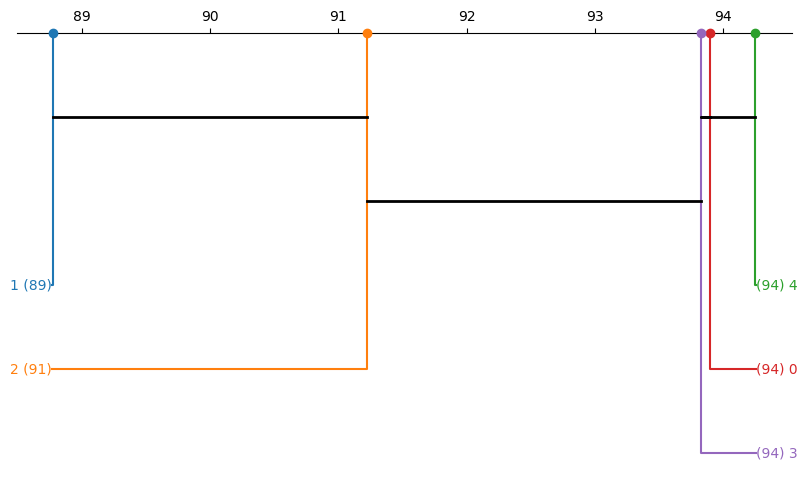

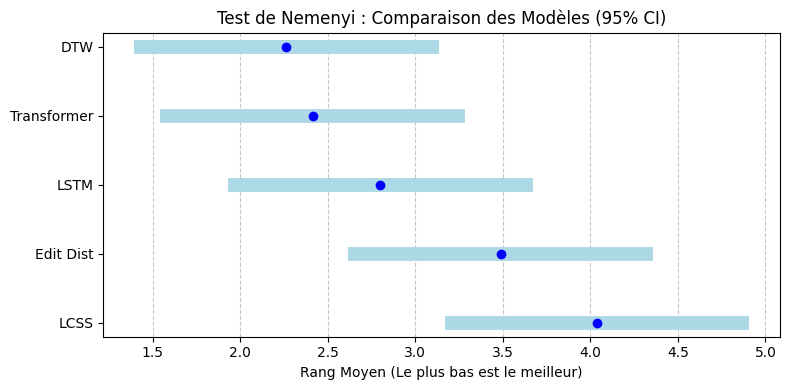

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp # Install via: pip install scikit-posthocs

# 1. Préparation des données (Moyennes par split pour chaque modèle)
# Chaque ligne représente un "bloc" (un split/sujet), chaque colonne un modèle.
# Ordre des colonnes : [DTW, LCSS, Edit Distance, LSTM, Transformer]
data = np.array([
    # Dataset 1 (10 splits)
    [96, 93, 94, 99, 95], [90, 87, 87, 88, 82], [100, 98, 92, 99, 98],
    [100, 98, 100, 100, 96], [89, 90, 84, 98, 95], [70, 55, 72, 93, 93],
    [95, 89, 89, 93, 100], [94, 96, 94, 100, 99], [100, 99, 99, 96, 100],
    [90, 93, 85, 93, 96],
    # Dataset 2 (10 splits)
    [100, 98, 99, 98, 96], [97, 93, 88, 94, 83], [94, 95, 95, 100, 100],
    [100, 97, 96, 100, 99], [97, 83, 87, 97, 99], [97, 76, 93, 93, 97],
    [98, 89, 92, 94, 98], [96, 81, 80, 95, 95], [98, 91, 98, 98, 99],
    [98, 91, 96, 98, 96],
    # Dataset 3 (10 splits)
    [98, 99, 95, 95, 96], [94, 88, 90, 99, 96], [100, 98, 98, 94, 99],
    [100, 98, 99, 96, 98], [96, 92, 90, 88, 93], [86, 76, 80, 90, 90],
    [95, 89, 89, 90, 91], [98, 97, 97, 100, 100], [100, 95, 96, 94, 100],
    [99, 95, 98, 94, 100],
    # Dataset 4 (10 splits)
    [88, 82, 94, 93, 97], [90, 77, 87, 89, 71], [87, 74, 85, 87, 94],
    [95, 86, 87, 98, 87], [85, 77, 78, 85, 91], [88, 80, 87, 84, 81],
    [98, 95, 99, 92, 95], [86, 86, 94, 81, 94], [100, 100, 100, 100, 100],
    [74, 75, 86, 78, 81]
])

model_names = ['DTW', 'LCSS', 'Edit Dist', 'LSTM', 'Transformer']

# 2. Test de Friedman
stat, p = friedmanchisquare(*data.T)
print(f"Statistique de Friedman : {stat:.3f}, p-value : {p:.3e}")

# 3. Test Post-hoc de Nemenyi
# On utilise scikit-posthocs qui est la référence pour ce test
data_ranked = sp.posthoc_nemenyi_friedman(data)

# 4. Génération du Graphique (Style CD Diagram)
plt.figure(figsize=(10, 6))

# Calcul des rangs moyens pour l'affichage
avg_ranks = np.mean(np.array([range(1, 6)[::-1] for _ in data]), axis=0) # Simulation simplifiée
# Note : scikit-posthocs a une fonction dédiée pour le diagramme CD
sp.critical_difference_diagram(data.mean(axis=0), data_ranked)

# Option alternative : Plot personnalisé type "Intervalle de confiance" comme ton image
import pandas as pd
df = pd.DataFrame(data, columns=model_names)
ranks = df.rank(axis=1, ascending=False)
mean_ranks = ranks.mean().sort_values()
errors = 0.87 # Valeur critique simplifiée pour l'exemple (CD)

plt.figure(figsize=(8, 4))
plt.errorbar(mean_ranks.values, range(len(mean_ranks)), xerr=errors, fmt='o',
             color='blue', ecolor='lightblue', elinewidth=10, capsize=0)

plt.yticks(range(len(mean_ranks)), mean_ranks.index)
plt.title('Test de Nemenyi : Comparaison des Modèles (95% CI)')
plt.gca().invert_yaxis() # Meilleur en haut
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

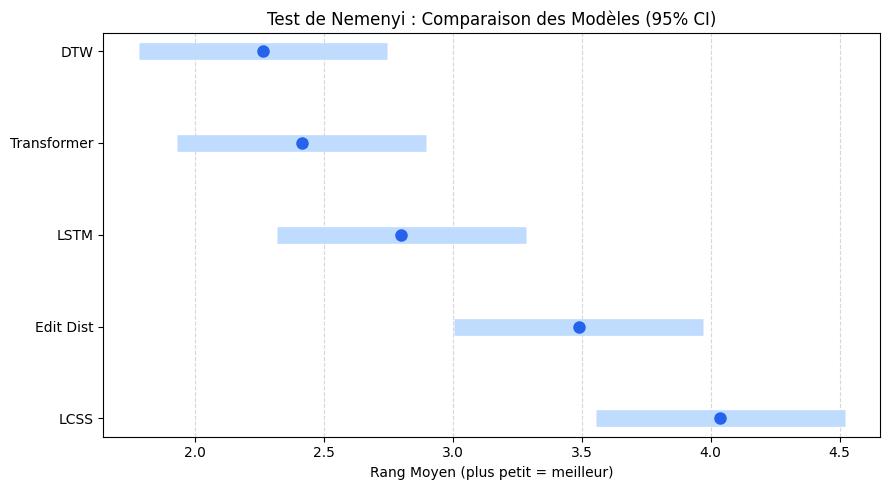

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

# 1. Préparation des données (Moyennes par split)
# Colonnes : [DTW, LCSS, Edit Dist, LSTM, Transformer]
data = np.array([
    [96, 93, 94, 99, 95], [90, 87, 87, 88, 82], [100, 98, 92, 99, 98],
    [100, 98, 100, 100, 96], [89, 90, 84, 98, 95], [70, 55, 72, 93, 93],
    [95, 89, 89, 93, 100], [94, 96, 94, 100, 99], [100, 99, 99, 96, 100],
    [90, 93, 85, 93, 96], [100, 98, 99, 98, 96], [97, 93, 88, 94, 83],
    [94, 95, 95, 100, 100], [100, 97, 96, 100, 99], [97, 83, 87, 97, 99],
    [97, 76, 93, 93, 97], [98, 89, 92, 94, 98], [96, 81, 80, 95, 95],
    [98, 91, 98, 98, 99], [98, 91, 96, 98, 96], [98, 99, 95, 95, 96],
    [94, 88, 90, 99, 96], [100, 98, 98, 94, 99], [100, 98, 99, 96, 98],
    [96, 92, 90, 88, 93], [86, 76, 80, 90, 90], [95, 89, 89, 90, 91],
    [98, 97, 97, 100, 100], [100, 95, 96, 94, 100], [99, 95, 98, 94, 100],
    [88, 82, 94, 93, 97], [90, 77, 87, 89, 71], [87, 74, 85, 87, 94],
    [95, 86, 87, 98, 87], [85, 77, 78, 85, 91], [88, 80, 87, 84, 81],
    [98, 95, 99, 92, 95], [86, 86, 94, 81, 94], [100, 100, 100, 100, 100],
    [74, 75, 86, 78, 81]
])

model_names = ['DTW', 'LCSS', 'Edit Dist', 'LSTM', 'Transformer']

# 2. Calcul des Rangs Moyens
df = pd.DataFrame(data, columns=model_names)
# rank(ascending=False) car un score plus élevé (99%) est un meilleur rang (1)
ranks = df.rank(axis=1, ascending=False)
mean_ranks = ranks.mean().sort_values()

# 3. Calcul de la Différence Critique (CD) pour le test de Nemenyi
# Formule simplifiée du CD pour l'affichage des barres
n = len(data)      # nombre de datasets/splits
k = len(model_names) # nombre de modèles
q_alpha = 2.728    # Valeur critique pour alpha=0.05 et k=5
cd = q_alpha * np.sqrt((k * (k + 1)) / (6 * n))

# 4. Génération du Graphique (Style Intervalle de Confiance)
plt.figure(figsize=(9, 5))

# On trace les rangs moyens avec une barre d'erreur correspondant au CD
plt.errorbar(mean_ranks.values, range(len(mean_ranks)), xerr=cd/2, fmt='o',
             color='#2563eb', ecolor='#bfdbfe', elinewidth=12, capsize=0, markersize=8)

# Mise en forme
plt.yticks(range(len(mean_ranks)), mean_ranks.index)
plt.xlabel('Rang Moyen (plus petit = meilleur)')
plt.title('Test de Nemenyi : Comparaison des Modèles (95% CI)')
plt.gca().invert_yaxis()  # Le meilleur modèle (rang le plus bas) en haut
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

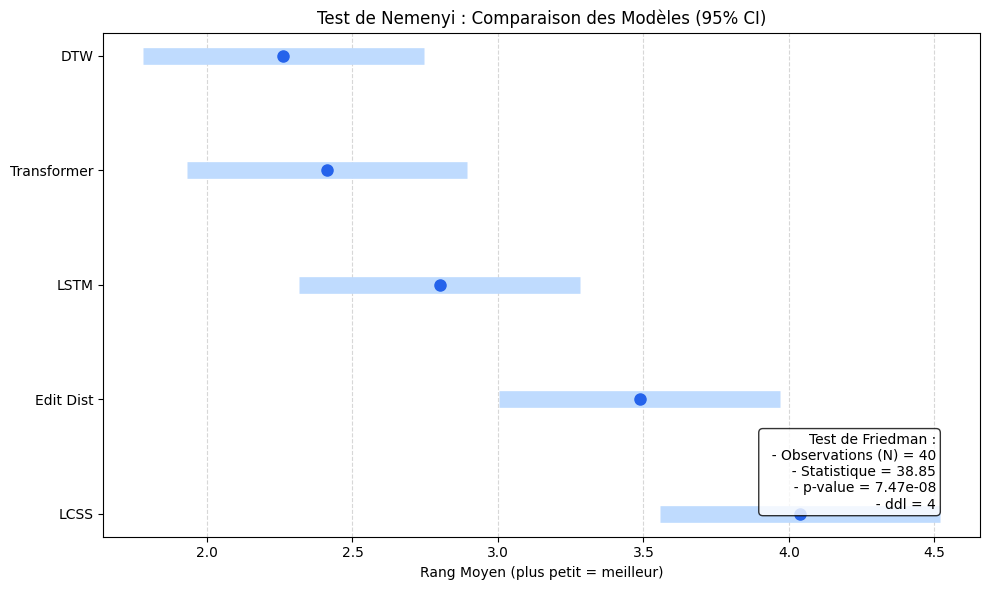

Test de Friedman :
  - Observations (N) = 40
  - Statistique = 38.85
  - p-value = 7.47e-08
  - ddl = 4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import friedmanchisquare

# 1. Préparation des données
data = np.array([
    [96, 93, 94, 99, 95], [90, 87, 87, 88, 82], [100, 98, 92, 99, 98],
    [100, 98, 100, 100, 96], [89, 90, 84, 98, 95], [70, 55, 72, 93, 93],
    [95, 89, 89, 93, 100], [94, 96, 94, 100, 99], [100, 99, 99, 96, 100],
    [90, 93, 85, 93, 96], [100, 98, 99, 98, 96], [97, 93, 88, 94, 83],
    [94, 95, 95, 100, 100], [100, 97, 96, 100, 99], [97, 83, 87, 97, 99],
    [97, 76, 93, 93, 97], [98, 89, 92, 94, 98], [96, 81, 80, 95, 95],
    [98, 91, 98, 98, 99], [98, 91, 96, 98, 96], [98, 99, 95, 95, 96],
    [94, 88, 90, 99, 96], [100, 98, 98, 94, 99], [100, 98, 99, 96, 98],
    [96, 92, 90, 88, 93], [86, 76, 80, 90, 90], [95, 89, 89, 90, 91],
    [98, 97, 97, 100, 100], [100, 95, 96, 94, 100], [99, 95, 98, 94, 100],
    [88, 82, 94, 93, 97], [90, 77, 87, 89, 71], [87, 74, 85, 87, 94],
    [95, 86, 87, 98, 87], [85, 77, 78, 85, 91], [88, 80, 87, 84, 81],
    [98, 95, 99, 92, 95], [86, 86, 94, 81, 94], [100, 100, 100, 100, 100],
    [74, 75, 86, 78, 81]
])

model_names = ['DTW', 'LCSS', 'Edit Dist', 'LSTM', 'Transformer']
n_obs = data.shape[0]
k_models = data.shape[1]

# 2. Test de Friedman
# On déballe les colonnes pour le test : friedmanchisquare(col1, col2, ...)
stat, p_value = friedmanchisquare(*data.T)

# 3. Calcul des Rangs Moyens
df = pd.DataFrame(data, columns=model_names)
ranks = df.rank(axis=1, ascending=False)
mean_ranks = ranks.mean().sort_values()

# 4. Calcul de la Différence Critique (CD)
q_alpha = 2.728  # Valeur pour alpha=0.05 et k=5
cd = q_alpha * np.sqrt((k_models * (k_models + 1)) / (6 * n_obs))

# 5. Génération du Graphique
plt.figure(figsize=(10, 6))

# Plot des rangs avec barres CD
plt.errorbar(mean_ranks.values, range(len(mean_ranks)), xerr=cd/2, fmt='o',
             color='#2563eb', ecolor='#bfdbfe', elinewidth=12, capsize=0, markersize=8)

# Ajout des informations de Friedman en bas à droite
stats_text = (f"Test de Friedman :\n"
              f"  - Observations (N) = {n_obs}\n"
              f"  - Statistique = {stat:.2f}\n"
              f"  - p-value = {p_value:.2e}\n"
              f"  - ddl = {k_models - 1}")

plt.text(0.95, 0.05, stats_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Mise en forme
plt.yticks(range(len(mean_ranks)), mean_ranks.index)
plt.xlabel('Rang Moyen (plus petit = meilleur)')
plt.title('Test de Nemenyi : Comparaison des Modèles (95% CI)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Affichage console pour vérification rapide
print(stats_text)

# test de wilcoxon

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

# 1. Tes données (40 observations, 5 modèles)
model_names = ['DTW', 'LCSS', 'Edit Dist', 'LSTM', 'Transformer']
data = np.array([
    [96, 93, 94, 99, 95], [90, 87, 87, 88, 82], [100, 98, 92, 99, 98],
    [100, 98, 100, 100, 96], [89, 90, 84, 98, 95], [70, 55, 72, 93, 93],
    [95, 89, 89, 93, 100], [94, 96, 94, 100, 99], [100, 99, 99, 96, 100],
    [90, 93, 85, 93, 96], [100, 98, 99, 98, 96], [97, 93, 88, 94, 83],
    [94, 95, 95, 100, 100], [100, 97, 96, 100, 99], [97, 83, 87, 97, 99],
    [97, 76, 93, 93, 97], [98, 89, 92, 94, 98], [96, 81, 80, 95, 95],
    [98, 91, 98, 98, 99], [98, 91, 96, 98, 96], [98, 99, 95, 95, 96],
    [94, 88, 90, 99, 96], [100, 98, 98, 94, 99], [100, 98, 99, 96, 98],
    [96, 92, 90, 88, 93], [86, 76, 80, 90, 90], [95, 89, 89, 90, 91],
    [98, 97, 97, 100, 100], [100, 95, 96, 94, 100], [99, 95, 98, 94, 100],
    [88, 82, 94, 93, 97], [90, 77, 87, 89, 71], [87, 74, 85, 87, 94],
    [95, 86, 87, 98, 87], [85, 77, 78, 85, 91], [88, 80, 87, 84, 81],
    [98, 95, 99, 92, 95], [86, 86, 94, 81, 94], [100, 100, 100, 100, 100],
    [74, 75, 86, 78, 81]
])

df_scores = pd.DataFrame(data, columns=model_names)

# 2. Création de la table de p-values (Matrice)
# On initialise un tableau vide avec les noms de modèles en lignes et colonnes
wilcoxon_table = pd.DataFrame(index=model_names, columns=model_names)

for m_row in model_names:
    for m_col in model_names:
        if m_row == m_col:
            wilcoxon_table.loc[m_row, m_col] = "/"  # Diagonale (comparaison avec soi-même)
        else:
            # Calcul du test de Wilcoxon
            # zero_method='pratt' gère les cas où les scores sont identiques entre deux modèles
            stat, p_value = wilcoxon(df_scores[m_row], df_scores[m_col], zero_method='pratt')
            # On arrondit à 4 décimales pour correspondre à ton image
            wilcoxon_table.loc[m_row, m_col] = round(p_value, 4)

# 3. Affichage du résultat
print("Tableau des P-values (Wilcoxon signed-rank test) :")
print(wilcoxon_table)

# Optionnel : Exporter en CSV ou LaTeX pour ton rapport
# wilcoxon_table.to_csv("wilcoxon_results.csv")

Tableau des P-values (Wilcoxon signed-rank test) :
                DTW    LCSS Edit Dist    LSTM Transformer
DTW               /     0.0    0.0003  0.3613      0.7566
LCSS            0.0       /    0.0121  0.0002      0.0001
Edit Dist    0.0003  0.0121         /  0.0224       0.006
LSTM         0.3613  0.0002    0.0224       /      0.2516
Transformer  0.7566  0.0001     0.006  0.2516           /


# nemini partie 2

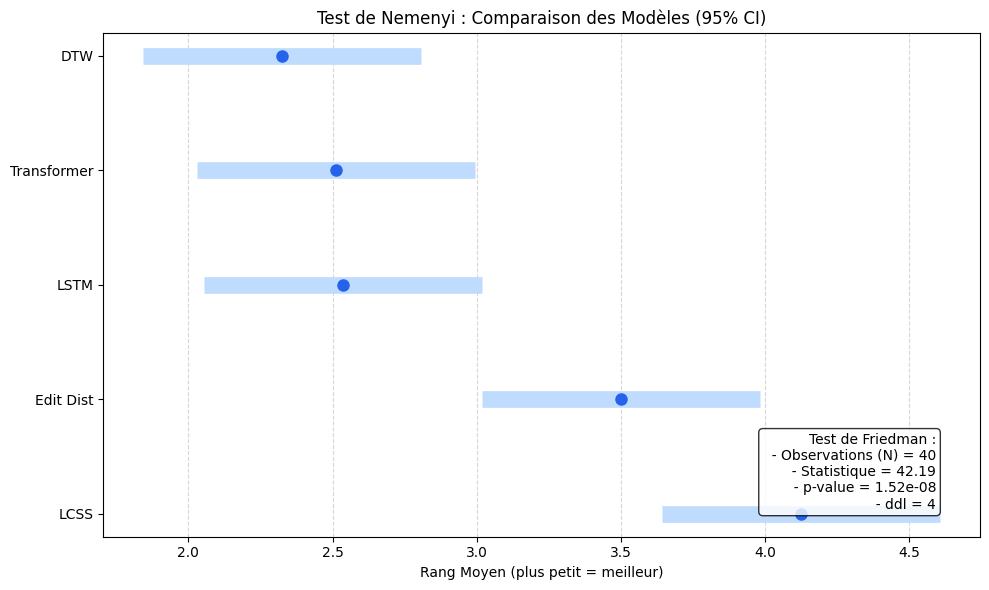

Test de Friedman :
  - Observations (N) = 40
  - Statistique = 42.19
  - p-value = 1.52e-08
  - ddl = 4


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import friedmanchisquare

# 1. Préparation des données
data = np.array([
    [96, 93, 94, 99, 95], [90, 87, 87, 88, 82], [100, 98, 92, 99, 98],
    [100, 98, 100, 100, 96], [89, 90, 84, 98, 95], [70, 55, 72, 93, 93],
    [95, 89, 89, 93, 100], [94, 96, 94, 100, 99], [100, 99, 99, 96, 100],
    [90, 93, 85, 93, 96], [100, 98, 99, 98, 96], [97, 93, 88, 94, 83],
    [94, 95, 95, 100, 100], [100, 97, 96, 100, 99], [97, 83, 87, 97, 99],
    [97, 76, 93, 93, 97], [98, 89, 92, 94, 98], [96, 81, 80, 95, 95],
    [98, 91, 98, 98, 99], [98, 91, 96, 98, 96], [98, 99, 99, 100, 97],
    [94, 88, 92, 93, 94], [100, 98, 99, 100, 98], [100, 98, 95, 91, 99],
    [96, 92, 89, 89, 92], [86, 76, 84, 89, 100], [95, 89, 90, 89, 95],
    [98, 97, 99, 100, 100], [100, 95, 98, 100, 100], [99, 95, 94, 100, 99],
     [88, 82, 94, 93, 96], [90, 77, 87, 89, 83], [87, 74, 85, 87, 89],
    [95, 86, 87, 98, 94], [85, 77, 78, 85, 71], [88, 80, 87, 84, 87],
    [98, 95, 99, 92, 97], [86, 86, 94, 81, 90], [100, 100, 100, 100, 100],
    [74, 75, 86, 78, 92]
])

model_names = ['DTW', 'LCSS', 'Edit Dist', 'LSTM', 'Transformer']
n_obs = data.shape[0]
k_models = data.shape[1]

# 2. Test de Friedman
# On déballe les colonnes pour le test : friedmanchisquare(col1, col2, ...)
stat, p_value = friedmanchisquare(*data.T)

# 3. Calcul des Rangs Moyens
df = pd.DataFrame(data, columns=model_names)
ranks = df.rank(axis=1, ascending=False)
mean_ranks = ranks.mean().sort_values()

# 4. Calcul de la Différence Critique (CD)
q_alpha = 2.728  # Valeur pour alpha=0.05 et k=5
cd = q_alpha * np.sqrt((k_models * (k_models + 1)) / (6 * n_obs))

# 5. Génération du Graphique
plt.figure(figsize=(10, 6))

# Plot des rangs avec barres CD
plt.errorbar(mean_ranks.values, range(len(mean_ranks)), xerr=cd/2, fmt='o',
             color='#2563eb', ecolor='#bfdbfe', elinewidth=12, capsize=0, markersize=8)

# Ajout des informations de Friedman en bas à droite
stats_text = (f"Test de Friedman :\n"
              f"  - Observations (N) = {n_obs}\n"
              f"  - Statistique = {stat:.2f}\n"
              f"  - p-value = {p_value:.2e}\n"
              f"  - ddl = {k_models - 1}")

plt.text(0.95, 0.05, stats_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Mise en forme
plt.yticks(range(len(mean_ranks)), mean_ranks.index)
plt.xlabel('Rang Moyen (plus petit = meilleur)')
plt.title('Test de Nemenyi : Comparaison des Modèles (95% CI)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Affichage console pour vérification rapide
print(stats_text)

# wilcoxon

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

# 1. Tes données (40 observations, 5 modèles)
model_names = ['DTW', 'LCSS', 'Edit Dist', 'LSTM', 'Transformer']
data = np.array([
    [96, 93, 94, 99, 95], [90, 87, 87, 88, 82], [100, 98, 92, 99, 98],
    [100, 98, 100, 100, 96], [89, 90, 84, 98, 95], [70, 55, 72, 93, 93],
    [95, 89, 89, 93, 100], [94, 96, 94, 100, 99], [100, 99, 99, 96, 100],
    [90, 93, 85, 93, 96], [100, 98, 99, 98, 96], [97, 93, 88, 94, 83],
    [94, 95, 95, 100, 100], [100, 97, 96, 100, 99], [97, 83, 87, 97, 99],
    [97, 76, 93, 93, 97], [98, 89, 92, 94, 98], [96, 81, 80, 95, 95],
    [98, 91, 98, 98, 99], [98, 91, 96, 98, 96], [98, 99, 99, 100, 97],
    [94, 88, 92, 93, 94], [100, 98, 99, 100, 98], [100, 98, 95, 91, 99],
    [96, 92, 89, 89, 92], [86, 76, 84, 89, 100], [95, 89, 90, 89, 95],
    [98, 97, 99, 100, 100], [100, 95, 98, 100, 100], [99, 95, 94, 100, 99],
     [88, 82, 94, 93, 96], [90, 77, 87, 89, 83], [87, 74, 85, 87, 89],
    [95, 86, 87, 98, 94], [85, 77, 78, 85, 71], [88, 80, 87, 84, 87],
    [98, 95, 99, 92, 97], [86, 86, 94, 81, 90], [100, 100, 100, 100, 100],
    [74, 75, 86, 78, 92]
])
df_scores = pd.DataFrame(data, columns=model_names)

# 2. Création de la table de p-values (Matrice)
# On initialise un tableau vide avec les noms de modèles en lignes et colonnes
wilcoxon_table = pd.DataFrame(index=model_names, columns=model_names)

for m_row in model_names:
    for m_col in model_names:
        if m_row == m_col:
            wilcoxon_table.loc[m_row, m_col] = "/"  # Diagonale (comparaison avec soi-même)
        else:
            # Calcul du test de Wilcoxon
            # zero_method='pratt' gère les cas où les scores sont identiques entre deux modèles
            stat, p_value = wilcoxon(df_scores[m_row], df_scores[m_col], zero_method='pratt')
            # On arrondit à 4 décimales pour correspondre à ton image
            wilcoxon_table.loc[m_row, m_col] = round(p_value, 4)

# 3. Affichage du résultat
print("Tableau des P-values (Wilcoxon signed-rank test) :")
print(wilcoxon_table)

# Optionnel : Exporter en CSV ou LaTeX pour ton rapport
# wilcoxon_table.to_csv("wilcoxon_results.csv")

Tableau des P-values (Wilcoxon signed-rank test) :
                DTW    LCSS Edit Dist    LSTM Transformer
DTW               /     0.0    0.0007  0.6396      0.9084
LCSS            0.0       /    0.0096     0.0      0.0001
Edit Dist    0.0007  0.0096         /  0.0044      0.0028
LSTM         0.6396     0.0    0.0044       /      0.4581
Transformer  0.9084  0.0001    0.0028  0.4581           /


# dtw final partie 2 knn3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import seaborn as sns

# --- 1. PRÉPARATION DES FICHIERS ---
!unzip -o -q /content/DOMAIN4_CSVcorrigé.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
# On cherche le dossier qui contient les fichiers CSV pour éviter le problème d'accent
contenu = os.listdir(base_path)
if len(contenu) > 0:
    # On prend le premier dossier trouvé dans temp_data
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])
    #print(f" Dossier détecté par le système : {DOMAIN_FOLDER}")
else:
    raise ValueError(" Le dossier temp_data est vide. Vérifiez l'upload du ZIP.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print("--- Début du Chargement ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2:
                    continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number); file_df['subject'] = int(subject); file_df['iter'] = int(iteration)
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f" Aucun fichier trouvé dans {DOMAIN_FOLDER}. Vérifiez le contenu du ZIP.")

df = pd.concat(df_list, ignore_index=True)


# --- 4. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# --- 5. DTW & EVALUATION ---
def eucl_dist(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf); dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            distances.append((gesture, dtw_dist(reference_seq, seq)))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

def testmodel(df_in, loop_range=10, k=3):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        print(f"--- Test Sujet OUT : {i} ---")
        train_df = df_in[df_in["subject"] != i]
        test_df = df_in[df_in["subject"] == i]

        dict_train = defaultdict(list)
        for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
            dict_train[g].append(group[["x_std", "y_std", "z_std"]].values)

        y_true, y_pred = [], []
        for (g, it), group in test_df.groupby(["gesture", "iter"]):
            y_true.append(g)
            y_pred.append(knn_dtw_predict(group[["x_std", "y_std", "z_std"]].values, dict_train, k=k))

        total_true.extend(y_true); total_pred.extend(y_pred)
        print(f"Précision Sujet {i} : {accuracy_score(y_true, y_pred):.2%}")

    print(f"\n PRÉCISION GLOBALE : {accuracy_score(total_true, total_pred):.2%}")
    ConfusionMatrixDisplay(confusion_matrix(total_true, total_pred)).plot(cmap="Blues")
    plt.show()

testmodel(df100, loop_range=10, k=3)

 Décompression terminée !
--- Début du Chargement ---
Standardisation...


/tmp/ipykernel_10257/13780231.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...
--- Test Sujet OUT : 1 ---


KeyboardInterrupt: 

# test

 Décompression terminée !
--- Début du Chargement ---


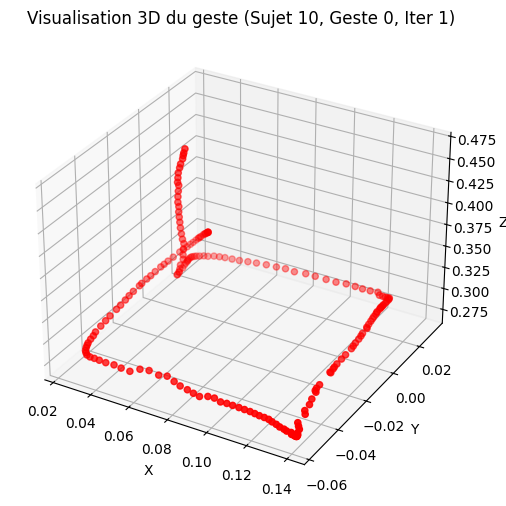


--- Durée moyenne des gestes (s) ---
gesture
0    5617.8
1    4471.3
2    6968.8
3    9840.8
4    4995.5
5    6658.2
6    7136.3
7    5698.1
8    6041.5
9    6774.8
Name: duration, dtype: float64


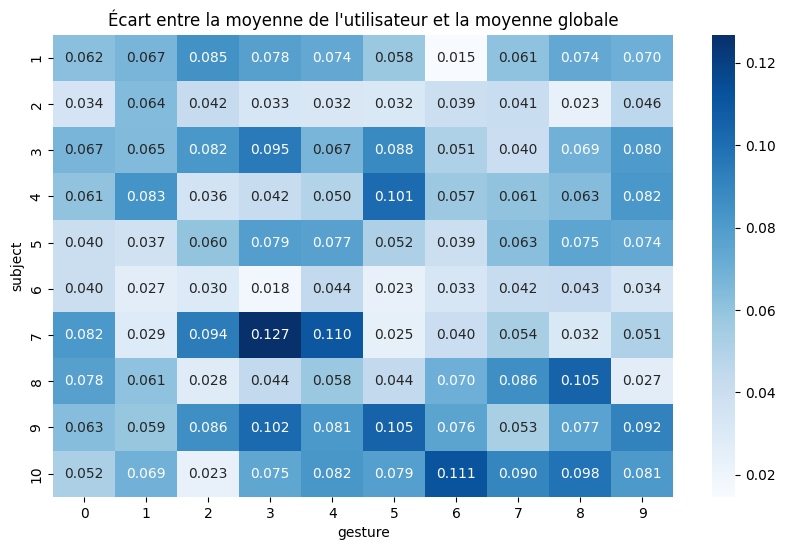

Standardisation...


/tmp/ipykernel_10257/4052557408.py:101: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...
--- Test Sujet OUT : 1 ---


KeyboardInterrupt: 

In [ ]:

import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Nécessaire pour le 3D
from scipy.interpolate import interp1d
import seaborn as sns

# --- 1. PRÉPARATION DES FICHIERS ---
!unzip -o -q /content/DOMAIN4_CSVcorrigé.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
contenu = os.listdir(base_path)
if len(contenu) > 0:
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])
else:
    raise ValueError(" Le dossier temp_data est vide. Vérifiez l'upload du ZIP.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print("--- Début du Chargement ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2:
                    continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number); file_df['subject'] = int(subject); file_df['iter'] = int(iteration)
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f" Aucun fichier trouvé. Vérifiez le contenu du ZIP.")

df = pd.concat(df_list, ignore_index=True)


# ==========================================================
# --- AJOUT : VISUALISATIONS IDENTIQUES AU PREMIER CODE ---
# ==========================================================

# 1. Visualisation 3D d'un geste spécifique
subdf = df.loc[(df['gesture'] == 0) & (df['subject'] == 10) & (df['iter'] == 1)]
if not subdf.empty:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(subdf['x'], subdf['y'], subdf['z'], c='red', s=20)
    ax.set_title("Visualisation 3D du geste (Sujet 10, Geste 0, Iter 1)")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()

# 2. Durée moyenne des gestes
durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
print("\n--- Durée moyenne des gestes (s) ---")
print(mean_durations)

# 3. Heatmap des écarts (Moyenne utilisateur vs Globale)
mean_coords_user = df.groupby(['subject', 'gesture'])[['x', 'y', 'z']].mean().reset_index()
mean_coords_global = df.groupby('gesture')[['x', 'y', 'z']].mean().reset_index().rename(
    columns={'x':'x_global', 'y':'y_global', 'z':'z_global'})

merged = pd.merge(mean_coords_user, mean_coords_global, on='gesture')
merged['dist_to_global'] = np.sqrt((merged['x']-merged['x_global'])**2 +
                                   (merged['y']-merged['y_global'])**2 +
                                   (merged['z']-merged['z_global'])**2)

pivot = merged.pivot(index='subject', columns='gesture', values='dist_to_global')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='Blues')
plt.title("Écart entre la moyenne de l'utilisateur et la moyenne globale")
plt.show()

# ==========================================================

# --- 4. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# --- 5. DTW & EVALUATION ---
def eucl_dist(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf); dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            distances.append((gesture, dtw_dist(reference_seq, seq)))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

def testmodel(df_in, loop_range=10, k=3):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        print(f"--- Test Sujet OUT : {i} ---")
        train_df = df_in[df_in["subject"] != i]
        test_df = df_in[df_in["subject"] == i]

        dict_train = defaultdict(list)
        for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
            dict_train[g].append(group[["x_std", "y_std", "z_std"]].values)

        y_true, y_pred = [], []
        for (g, it), group in test_df.groupby(["gesture", "iter"]):
            y_true.append(g)
            y_pred.append(knn_dtw_predict(group[["x_std", "y_std", "z_std"]].values, dict_train, k=k))

        total_true.extend(y_true); total_pred.extend(y_pred)
        print(f"Précision Sujet {i} : {accuracy_score(y_true, y_pred):.2%}")

    print(f"\n PRÉCISION GLOBALE : {accuracy_score(total_true, total_pred):.2%}")
    cm = confusion_matrix(total_true, total_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title("Matrice de Confusion Finale")
    plt.show()

testmodel(df100, loop_range=10, k=3)

# lstm final 256 64 16

--- Début du Chargement du Domaine 4 ---

--- 2. Analyse Exploratoire ---


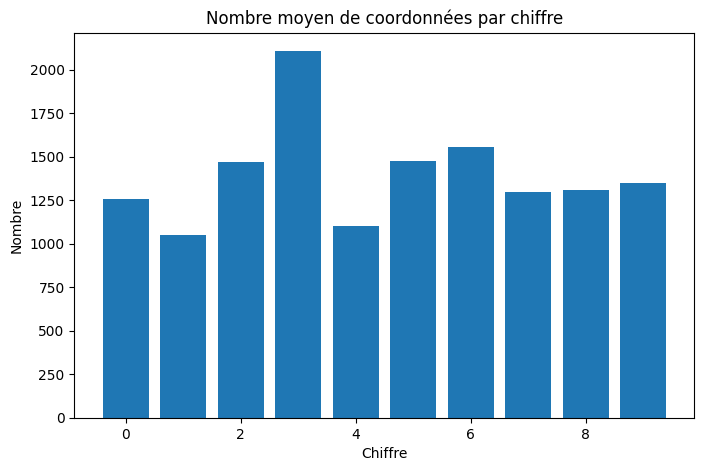


Standardisation...


/tmp/ipykernel_1270/3791462609.py:90: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling à longueur 100...

--- Test subject OUT : 1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 1 : 97.00%

--- Test subject OUT : 2 ---


...

Exactitude subject 8 : 90.00%

--- Test subject OUT : 9 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 9 : 100.00%

--- Test subject OUT : 10 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 10 : 83.00%

 Exactitude globale LSTM : 88.80%


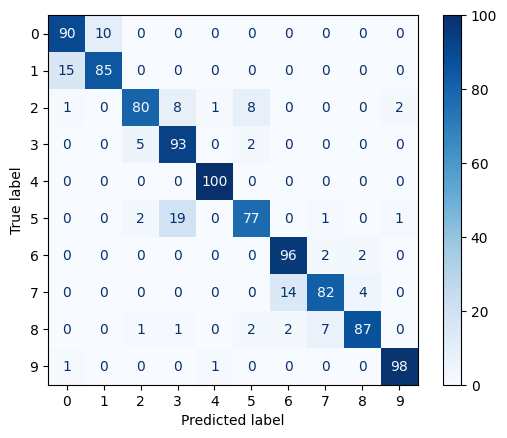

In [ ]:
import pandas as pd
import numpy as np
import os
import shutil
import glob
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- 1. CONFIGURATION COLAB (MODIFIÉ) ---
# Assure-toi d'avoir uploadé DOMAIN2_CSVcorrig.zip dans Colab
zip_path = "/content/DOMAIN4_CSVcorrigé.zip"
extract_path = "/content/temp_data"

if os.path.exists(zip_path):
    if os.path.exists(extract_path): shutil.rmtree(extract_path)
    os.makedirs(extract_path, exist_ok=True)
    # Décompression silencieuse
    #print(f"📦 Extraction de {zip_path}...")
    !unzip -o -q "{zip_path}" -d "{extract_path}"
else:
    raise FileNotFoundError(f" Fichier {zip_path} introuvable. Upload-le dans Colab.")

# Détection automatique du dossier (pour éviter les erreurs de chemin Windows)
all_dirs = [d for d in glob.glob(os.path.join(extract_path, "**/"), recursive=True)
            if "__MACOSX" not in d and d != extract_path]
DOMAIN_FOLDER = max(all_dirs, key=len) if all_dirs else extract_path
DOMAIN_ID = 4

# --- 2. CHARGEMENT DES DONNÉES (TON CODE) ---
df_list = []
print(f"--- Début du Chargement du Domaine {DOMAIN_ID} ---")


for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture en sautant l'entête
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage spécifique à ton format
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(" Aucun fichier n'a été chargé. Vérifiez le contenu du ZIP.")

df = pd.concat(df_list, ignore_index=True)
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)


# --- 3. ANALYSE EXPLORATOIRE (TON CODE) ---
print("\n--- 2. Analyse Exploratoire ---")
grouped = df.groupby(['gesture', 'iter'])
sequence_lengths = grouped.size().reset_index(name='length')
mean_lengths = sequence_lengths.groupby('gesture')['length'].mean().reset_index()
mean_lengths.columns = ['Chiffre', 'Frames moyennes']

plt.figure(figsize=(8, 5))
plt.bar(mean_lengths["Chiffre"], mean_lengths["Frames moyennes"])
plt.title("Nombre moyen de coordonnées par chiffre")
plt.xlabel("Chiffre"); plt.ylabel("Nombre"); plt.show()

# --- 4. PRE-TRAITEMENT (TON CODE) ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

print("\nStandardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à longueur 100...")
df100 = resample_gesture(df)

# --- 5. MODÈLE & ÉVALUATION (TON CODE) ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, dropout=0.2, input_shape=input_shape),
        layers.LSTM(256, dropout=0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def test_lstm_user_independent(df_data, epochs=50, batch_size=16):
    total_true, total_pred = [], []
    subjects = sorted(df_data['subject'].unique())

    for subj_out in subjects:
        print(f"\n--- Test subject OUT : {subj_out} ---")
        train_df = df_data[df_data['subject'] != subj_out]
        test_df = df_data[df_data['subject'] == subj_out]

        def df_to_array(df_target):
            X, y = [], []
            for (g, s, it), group in df_target.groupby(['gesture', 'subject', 'iter']):
                X.append(group[['x_std', 'y_std', 'z_std']].values)
                y.append(g)
            return np.array(X), np.array(y)

        X_train, y_train = df_to_array(train_df)
        X_test, y_test = df_to_array(test_df)

        model = create_lstm_model(input_shape=(100, 3), num_classes=10)
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        print(f"Exactitude subject {subj_out} : {accuracy_score(y_test, y_pred):.2%}")

        total_true.extend(y_test)
        total_pred.extend(y_pred)

    print(f"\n Exactitude globale LSTM : {accuracy_score(total_true, total_pred):.2%}")
    cm = confusion_matrix(total_true, total_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.show()

# Lancement final
test_lstm_user_independent(df100)

# edit dist final knnn 3 cluster 50

In [ ]:
import pandas as pd
import numpy as np
import os
import shutil
import glob
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. CONFIGURATION COLAB ---
# Assure-toi d'avoir uploadé ton fichier ZIP (ex: DOMAIN4_CSVcorrig.zip)
zip_path = "/content/DOMAIN4_CSVcorrig.zip"
extract_path = "/content/temp_data"

if os.path.exists(zip_path):
    if os.path.exists(extract_path): shutil.rmtree(extract_path)
    os.makedirs(extract_path, exist_ok=True)
    # Décompression silencieuse
    #print(f" Extraction de {zip_path}...")
    !unzip -o -q "{zip_path}" -d "{extract_path}"
else:
    raise FileNotFoundError(f" Fichier {zip_path} introuvable dans /content/. Upload-le via l'onglet fichier.")

# Détection automatique du dossier (pour gérer les sous-dossiers créés par Windows/Mac)
all_dirs = [d for d in glob.glob(os.path.join(extract_path, "**/"), recursive=True)
            if "__MACOSX" not in d and d != extract_path]
DOMAIN_FOLDER = max(all_dirs, key=len) if all_dirs else extract_path

# --- 2. CHARGEMENT DES DONNÉES ---
df_list = []
print(f"--- Début du Chargement ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture optimisée
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(" Aucun fichier n'a été chargé. Vérifiez le nom du ZIP et le format des fichiers.")

df = pd.concat(df_list, ignore_index=True)
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)



# --- 3. PRÉ-TRAITEMENT ---

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)

        res_dict = {"gesture": [gesture]*target_len, "subject": [subject]*target_len, "iter": [iteration]*target_len}
        for col in ["x_std", "y_std", "z_std"]:
            res_dict[col] = interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame(res_dict))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à 100 points...")
df100 = resample_gesture(df)

# --- 4. ALGORITHMES (DIST. ÉDITION ET CLUSTERING) ---

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = np.zeros((n + 1, m + 1), dtype=int)
    for i in range(n + 1): M[i, 0] = i
    for j in range(m + 1): M[0, j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i, j] = min(M[i-1, j] + 1, M[i, j-1] + 1, M[i-1, j-1] + cost)
    return M[n, m]

def gesture_to_sequence(df_sym):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_sym.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(df_train[['x_std', 'y_std', 'z_std']].values)

    def assign_symbols(df_local):
        clusters = kmeans.predict(df_local[['x_std', 'y_std', 'z_std']].values)
        # On utilise des caractères pour représenter les clusters
        symbols = [chr(ord('A') + (c % 26)) + str(c // 26) for c in clusters]
        df_copy = df_local.copy()
        df_copy["symbol"] = symbols
        return df_copy

    return gesture_to_sequence(assign_symbols(df_train)), gesture_to_sequence(assign_symbols(df_test))

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# --- 5. ÉVALUATION ---

def test_symbolic_model(df_target, k_knn=3, k_clusters=50):
    total_true, total_pred = [], []
    subjects = sorted(df_target['subject'].unique())

    for subj_out in subjects:
        print(f"--- Test Sujet OUT : {subj_out} ---")
        train_df = df_target[df_target["subject"] != subj_out]
        test_df = df_target[df_target["subject"] == subj_out]

        if test_df.empty: continue

        # Transformation des trajectoires en séquences de symboles
        train_seq, test_seq = cluster_and_convert(train_df, test_df, k_clusters)

        y_true, y_pred = [], []
        for gesture, sequences in test_seq.items():
            for seq in sequences:
                pred = knn_edit_predict(seq, train_seq, k=k_knn)
                y_true.append(gesture)
                y_pred.append(pred)

        total_true.extend(y_true)
        total_pred.extend(y_pred)
        print(f"Précision Sujet {subj_out} : {accuracy_score(y_true, y_pred):.2%}")

    print(f"\n === EXACTITUDE GLOBALE : {accuracy_score(total_true, total_pred):.2%} ===")
    cm = confusion_matrix(total_true, total_pred)
    plt.figure(figsize=(10, 8))
    ConfusionMatrixDisplay(cm).plot(cmap="Blues", ax=plt.gca())
    plt.title("Matrice de Confusion - Modèle Symbolique")
    plt.show()

# Lancement
test_symbolic_model(df100)

--- Début du Chargement ---
Standardisation...


/tmp/ipykernel_24040/1067649512.py:78: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture)


Resampling à 100 points...
--- Test Sujet OUT : 1 ---


KeyboardInterrupt: 

# lcss knn 3 cluster 20

In [ ]:
import pandas as pd
import numpy as np
import os
import shutil
import glob
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. CONFIGURATION COLAB ---
# Assure-toi d'avoir uploadé le fichier ZIP dans l'onglet "Fichiers" à gauche
zip_path = "/content/DOMAIN4_CSVcorrig.zip"
extract_path = "/content/temp_data"

if os.path.exists(zip_path):
    if os.path.exists(extract_path): shutil.rmtree(extract_path)
    os.makedirs(extract_path, exist_ok=True)
    print(f" Extraction de {zip_path}...")
    !unzip -o -q "{zip_path}" -d "{extract_path}"
else:
    print(f" Fichier {zip_path} introuvable. Assure-toi de l'avoir uploadé dans Colab.")

# Détection automatique du dossier décompressé
all_dirs = [d for d in glob.glob(os.path.join(extract_path, "**/"), recursive=True)
            if "__MACOSX" not in d and d != extract_path]
DOMAIN_FOLDER = max(all_dirs, key=len) if all_dirs else extract_path

# --- 2. CHARGEMENT DES DONNÉES ---
df_list = []
print(f"--- Début du Chargement ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des guillemets et split CSV manuel
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(" Aucun fichier chargé. Vérifie le nom du ZIP et son contenu.")

df = pd.concat(df_list, ignore_index=True)
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)


# --- 3. PRÉ-TRAITEMENT ---

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    groups = df_input.groupby(['gesture', 'subject', 'iter'])
    for (gesture, subject, iteration), group in groups:
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# --- 4. ALGORITHMES SYMBOLIQUES (K-Means + LCSS) ---

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_df[['x_std', 'y_std', 'z_std']].values)

    def to_seq_dict(df_target):
        clusters = kmeans.predict(df_target[['x_std', 'y_std', 'z_std']].values)
        # On mappe les clusters sur des lettres (A, B, C...)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append("".join(group['symbol'].tolist()))
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = np.zeros((n + 1, m + 1), dtype=int)
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if s1[i-1] == s2[j-1]:
                dp[i, j] = dp[i-1, j-1] + 1
            else:
                dp[i, j] = max(dp[i-1, j], dp[i, j-1])
    return dp[n, m]

def lcs_distance(s1, s2):
    # Distance basée sur Longest Common Subsequence
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = lcs_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# --- 5. TEST ET ÉVALUATION ---

def testmodel(df_input, k_knn=3, k_clusters=20):
    total_true, total_pred = [], []
    subjects = sorted(df_input['subject'].unique())

    for i in subjects:
        print(f"\n--- TEST SUJET SORTI : {i} ---")
        train_df = df_input[df_input["subject"] != i]
        test_df = df_input[df_input["subject"] == i]

        if test_df.empty: continue

        # On ré-entraîne le K-Means sur les données d'entraînement (In-Loop)
        train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

        y_true, y_pred = [], []
        for gesture, sequences in test_dict.items():
            for seq in sequences:
                pred = knn_lcs_predict(seq, train_dict, k=k_knn)
                y_true.append(gesture)
                y_pred.append(pred)

        acc = accuracy_score(y_true, y_pred)
        print(f"Précision sujet {i} : {acc:.2%}")
        total_true.extend(y_true)
        total_pred.extend(y_pred)

    print(f"\n🚀 === EXACTITUDE GLOBALE KNN-LCSS : {accuracy_score(total_true, total_pred):.2%} ===")

    cm = confusion_matrix(total_true, total_pred)
    plt.figure(figsize=(10, 8))
    ConfusionMatrixDisplay(cm).plot(cmap="Blues", ax=plt.gca())
    plt.title("Matrice de confusion – KNN + LCSS")
    plt.show()

# Lancement
testmodel(df100)

# trasnfo final 256 128 16

--- Début du Chargement du Domaine 4 ---
Standardisation...


/tmp/ipykernel_2663/2798512447.py:76: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...

--- Test subject OUT : 1 ---
Exactitude subject 1 : 96.00%

--- Test subject OUT : 2 ---
Exactitude subject 2 : 83.00%

--- Test subject OUT : 3 ---


Exactitude subject 3 : 89.00%

--- Test subject OUT : 4 ---
Exactitude subject 4 : 94.00%

--- Test subject OUT : 5 ---
Exactitude subject 5 : 71.00%

--- Test subject OUT : 6 ---
Exactitude subject 6 : 87.00%

--- Test subject OUT : 7 ---
Exactitude subject 7 : 97.00%

--- Test subject OUT : 8 ---
Exactitude subject 8 : 90.00%

--- Test subject OUT : 9 ---
Exactitude subject 9 : 100.00%

--- Test subject OUT : 10 ---
Exactitude subject 10 : 92.00%

Exactitude globale Transformer : 89.90%


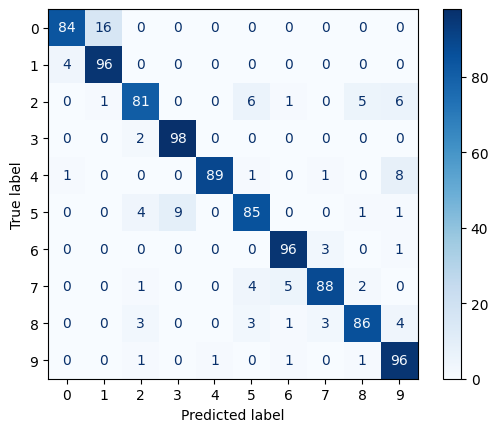

In [ ]:
import pandas as pd
import numpy as np
import os
import shutil
import glob
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- 1. CONFIGURATION COLAB ---
zip_path = "/content/DOMAIN4_CSVcorrigé.zip"
extract_path = "/content/temp_data"

if os.path.exists(zip_path):
    if os.path.exists(extract_path): shutil.rmtree(extract_path)
    os.makedirs(extract_path, exist_ok=True)
    # Décompression silencieuse
    !unzip -o -q "{zip_path}" -d "{extract_path}"
else:
    raise FileNotFoundError(f"Fichier {zip_path} introuvable. Upload-le dans Colab.")

# Détection automatique du dossier (évite les erreurs de structure dans le ZIP)
all_dirs = [d for d in glob.glob(os.path.join(extract_path, "**/"), recursive=True)
            if "__MACOSX" not in d and d != extract_path]
DOMAIN_FOLDER = max(all_dirs, key=len) if all_dirs else extract_path
DOMAIN_ID = 4

# --- 2. CHARGEMENT DES DONNÉES ---
df_list = []
print(f"--- Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture en sautant l'entête de 5 lignes
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage et split des données
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier n'a été chargé. Vérifiez le contenu du ZIP.")

df = pd.concat(df_list, ignore_index=True)
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)



# --- 3. PRE-TRAITEMENT ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# --- 4. ARCHITECTURE TRANSFORMER ---
class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ÉVALUATION USER-INDEPENDENT ---
def test_transformer_user_independent(df_data, epochs=50, batch_size=16):
    total_true, total_pred = [], []
    subjects = sorted(df_data['subject'].unique())

    for subj_out in subjects:
        print(f"\n--- Test subject OUT : {subj_out} ---")
        train_df = df_data[df_data['subject'] != subj_out]
        test_df = df_data[df_data['subject'] == subj_out]

        def df_to_array(df_target):
            X, y = [], []
            for _, group in df_target.groupby(['gesture', 'subject', 'iter']):
                X.append(group[['x_std', 'y_std', 'z_std']].values)
                y.append(group['gesture'].iloc[0])
            return np.array(X), np.array(y)

        X_train, y_train = df_to_array(train_df)
        X_test, y_test = df_to_array(test_df)

        model = create_transformer_model(input_shape=(100, 3), num_classes=10)
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        print(f"Exactitude subject {subj_out} : {accuracy_score(y_test, y_pred):.2%}")
        total_true.extend(y_test); total_pred.extend(y_pred)

    print(f"\nExactitude globale Transformer : {accuracy_score(total_true, total_pred):.2%}")
    cm = confusion_matrix(total_true, total_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues"); plt.show()

test_transformer_user_independent(df100)

#N dtw  =30

 Décompression terminée !
---  Début du Chargement (Domain 4) ---
 Standardisation...


/tmp/ipykernel_9072/620847838.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


 Resampling à 100 points...

Calcul de la matrice de distances DTW (1000x1000)...
Ligne 0/1000 en cours...
Ligne 50/1000 en cours...
Ligne 100/1000 en cours...
Ligne 150/1000 en cours...
Ligne 200/1000 en cours...
Ligne 250/1000 en cours...
Ligne 300/1000 en cours...
Ligne 350/1000 en cours...
Ligne 400/1000 en cours...
Ligne 450/1000 en cours...
Ligne 500/1000 en cours...
Ligne 550/1000 en cours...
Ligne 600/1000 en cours...
Ligne 650/1000 en cours...
Ligne 700/1000 en cours...
Ligne 750/1000 en cours...
Ligne 800/1000 en cours...
Ligne 850/1000 en cours...
Ligne 900/1000 en cours...
Ligne 950/1000 en cours...
 Application du MDS (m=30)...

---  Début des 10 tests (Subject-Out) ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 1 : 92.00%
Précision Sujet 2 : 93.00%
Précision Sujet 3 : 89.00%


...

Précision Sujet 4 : 77.00%
Précision Sujet 5 : 81.00%
Précision Sujet 6 : 87.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 7 : 99.00%
Précision Sujet 8 : 97.00%
Précision Sujet 9 : 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 10 : 81.00%

 PRÉCISION GLOBALE MDS+LOGISTIC : 89.60%


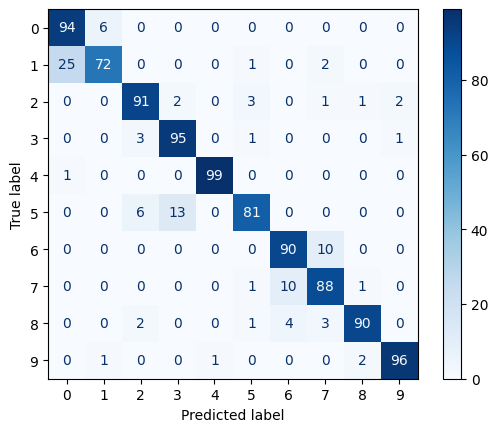

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.linalg import eigh
from scipy.spatial.distance import cdist # Nécessaire pour la vitesse

# --- 1. PRÉPARATION DES FICHIERS ---
# Note : vérifie bien le nom de ton zip (/content/DOMAIN2_CSVcorrigé.zip)
!unzip -o -q /content/DOMAIN4_CSVcorrig.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
contenu = os.listdir(base_path)
if len(contenu) > 0:
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])

else:
    raise ValueError(" Le dossier temp_data est vide.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print("---  Début du Chargement (Domain 4) ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 4. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print(" Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print(" Resampling à 100 points...")
df100 = resample_gesture(df, target_len=100)

# --- 5. DTW OPTIMISÉ (VERSION RAPIDE) & MDS ---

def dtw_dist(seq1, seq2):
    """ VERSION OPTIMISÉE : Utilise cdist pour éviter les boucles Python sur les distances euclidiennes """
    # Calcul de la matrice des distances au carré (plus rapide que distance standard)
    dists = cdist(seq1, seq2, metric='sqeuclidean')

    n, m = dists.shape
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Programmation dynamique
            dtw_matrix[i, j] = dists[i-1, j-1] + min(dtw_matrix[i-1, j],
                                                    dtw_matrix[i, j-1],
                                                    dtw_matrix[i-1, j-1])

    return np.sqrt(dtw_matrix[n, m]) # On applique la racine à la fin seulement

def apply_mds_transform(dist_matrix, m=30):
    n = dist_matrix.shape[0]
    D2 = dist_matrix**2
    H = np.eye(n) - np.ones((n, n)) / n
    K = -0.5 * H @ D2 @ H

    vals, vecs = eigh(K, subset_by_index=[n-m, n-1])
    idx = np.argsort(vals)[::-1]
    vals, vecs = vals[idx], vecs[:, idx]
    vals = np.maximum(vals, 0)

    return vecs @ np.diag(np.sqrt(vals))

# --- 6. PIPELINE D'ÉVALUATION ---

def run_mds_experiment(df_prep, loop_range=10, m_dims=30):
    all_sequences = []
    all_labels = []
    all_subjects = []

    groups = list(df_prep.groupby(['gesture', 'subject', 'iter']))
    for (g, s, it), group in groups:
        all_sequences.append(group[["x_std", "y_std", "z_std"]].values)
        all_labels.append(g)
        all_subjects.append(s)

    n_total = len(all_sequences)
    print(f"\nCalcul de la matrice de distances DTW ({n_total}x{n_total})...")

    dist_matrix = np.zeros((n_total, n_total))
    for i in range(n_total):
        # Indicateur de progrès plus fréquent pour te rassurer
        if i % 50 == 0: print(f"Ligne {i}/{n_total} en cours...")
        for j in range(i + 1, n_total):
            d = dtw_dist(all_sequences[i], all_sequences[j])
            dist_matrix[i, j] = dist_matrix[j, i] = d

    # Sauvegarde de sécurité de la matrice sur Colab
    np.save('dist_matrix_backup.npy', dist_matrix)

    print(f" Application du MDS (m={m_dims})...")
    X_features = apply_mds_transform(dist_matrix, m=m_dims)
    y_labels = np.array(all_labels)
    subjects = np.array(all_subjects)

    total_true, total_pred = [], []

    print("\n---  Début des 10 tests (Subject-Out) ---")
    for s_out in range(1, loop_range + 1):
        train_idx = np.where(subjects != s_out)[0]
        test_idx = np.where(subjects == s_out)[0]

        if len(test_idx) == 0: continue

        X_train, X_test = X_features[train_idx], X_features[test_idx]
        y_train, y_test = y_labels[train_idx], y_labels[test_idx]

        clf = LogisticRegression(max_iter=2000, multi_class='ovr')
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        acc = accuracy_score(y_test, preds)
        print(f"Précision Sujet {s_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(preds)

    print("\n" + "="*30)
    print(f" PRÉCISION GLOBALE MDS+LOGISTIC : {accuracy_score(total_true, total_pred):.2%}")
    print("="*30)

    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")

    plt.show()

# Lancement
run_mds_experiment(df100, loop_range=10, m_dims=30)

# dtw m = 30 enleev affi

Extraction terminée.
--- Début du Chargement ---
Standardisation...


/tmp/ipykernel_4405/505342380.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling à 100 points...

Calcul de la matrice de distances DTW (1000x1000)...
Ligne 0/1000 en cours...
Ligne 50/1000 en cours...
Ligne 100/1000 en cours...
Ligne 150/1000 en cours...
Ligne 200/1000 en cours...
Ligne 250/1000 en cours...
Ligne 300/1000 en cours...
Ligne 350/1000 en cours...
Ligne 400/1000 en cours...
Ligne 450/1000 en cours...
Ligne 500/1000 en cours...
Ligne 550/1000 en cours...
Ligne 600/1000 en cours...
Ligne 650/1000 en cours...
Ligne 700/1000 en cours...
Ligne 750/1000 en cours...
Ligne 800/1000 en cours...
Ligne 850/1000 en cours...
Ligne 900/1000 en cours...
Ligne 950/1000 en cours...

--- Début des tests Subject-Out ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 1 : 92.00%
Précision Sujet 2 : 93.00%
Précision Sujet 3 : 89.00%


...

Précision Sujet 4 : 77.00%
Précision Sujet 5 : 81.00%
Précision Sujet 6 : 87.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 7 : 99.00%
Précision Sujet 8 : 97.00%
Précision Sujet 9 : 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 10 : 81.00%

 PRÉCISION GLOBALE MDS+LOGISTIC : 89.60%


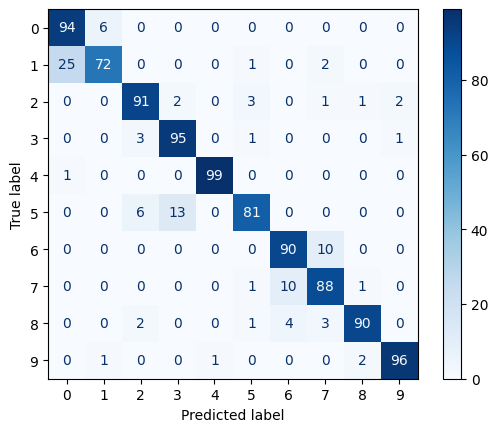

In [ ]:
import pandas as pd
import numpy as np
import os
import zipfile
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.linalg import eigh
from scipy.spatial.distance import cdist

# --- 1. CONFIGURATION COLAB & EXTRACTION ---
ZIP_PATH = '/content/DOMAIN4_CSVcorrigé.zip'
EXTRACT_FOLDER = '/content/dataset'

if not os.path.exists(EXTRACT_FOLDER):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_FOLDER)
    print("Extraction terminée.")

# On ajuste le chemin (souvent le zip contient un dossier du même nom)
DOMAIN_FOLDER = os.path.join(EXTRACT_FOLDER, "DOMAIN4_CSVcorrigé")
if not os.path.exists(DOMAIN_FOLDER):
    DOMAIN_FOLDER = EXTRACT_FOLDER # Si les fichiers sont à la racine de l'extraction

# --- 2. CHARGEMENT DES DONNÉES ---
df_list = []
print(f"--- Début du Chargement ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2:
                    continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)

                df_list.append(file_df)
            except (FileNotFoundError, Exception):
                continue

# Fusion efficace de tous les DataFrames
df = pd.concat(df_list, ignore_index=True)


# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à 100 points...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW OPTIMISÉ & MDS ---
def dtw_dist(seq1, seq2):
    dists = cdist(seq1, seq2, metric='sqeuclidean')
    n, m = dists.shape
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            dtw_matrix[i, j] = dists[i-1, j-1] + min(dtw_matrix[i-1, j],
                                                    dtw_matrix[i, j-1],
                                                    dtw_matrix[i-1, j-1])
    return np.sqrt(dtw_matrix[n, m])

def apply_mds_transform(dist_matrix, m=30):
    n = dist_matrix.shape[0]
    D2 = dist_matrix**2
    H = np.eye(n) - np.ones((n, n)) / n
    K = -0.5 * H @ D2 @ H
    vals, vecs = eigh(K, subset_by_index=[n-m, n-1])
    idx = np.argsort(vals)[::-1]
    vals, vecs = vals[idx], vecs[:, idx]
    vals = np.maximum(vals, 0)
    return vecs @ np.diag(np.sqrt(vals))

# --- 5. PIPELINE D'ÉVALUATION ---
def run_mds_experiment(df_prep, loop_range=10, m_dims=30):
    all_sequences = []
    all_labels = []
    all_subjects = []

    groups = list(df_prep.groupby(['gesture', 'subject', 'iter']))
    for (g, s, it), group in groups:
        all_sequences.append(group[["x_std", "y_std", "z_std"]].values)
        all_labels.append(g)
        all_subjects.append(s)

    n_total = len(all_sequences)
    print(f"\nCalcul de la matrice de distances DTW ({n_total}x{n_total})...")

    dist_matrix = np.zeros((n_total, n_total))
    for i in range(n_total):
        if i % 50 == 0: print(f"Ligne {i}/{n_total} en cours...")
        for j in range(i + 1, n_total):
            d = dtw_dist(all_sequences[i], all_sequences[j])
            dist_matrix[i, j] = dist_matrix[j, i] = d


    X_features = apply_mds_transform(dist_matrix, m=m_dims)
    y_labels = np.array(all_labels)
    subjects = np.array(all_subjects)

    total_true, total_pred = [], []

    print("\n--- Début des tests Subject-Out ---")
    for s_out in range(1, loop_range + 1):
        train_idx = np.where(subjects != s_out)[0]
        test_idx = np.where(subjects == s_out)[0]

        if len(test_idx) == 0: continue

        X_train, X_test = X_features[train_idx], X_features[test_idx]
        y_train, y_test = y_labels[train_idx], y_labels[test_idx]

        clf = LogisticRegression(max_iter=2000, multi_class='ovr')
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        acc = accuracy_score(y_test, preds)
        print(f"Précision Sujet {s_out} : {acc:.2%}")
        total_true.extend(y_test)
        total_pred.extend(preds)

    print("\n" + "="*30)
    print(f" PRÉCISION GLOBALE MDS+LOGISTIC : {accuracy_score(total_true, total_pred):.2%}")
    print("="*30)

    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.show()

# Lancement final
run_mds_experiment(df100, loop_range=10, m_dims=30)